###### GLOBAL WATER CONSUMPTION ANALYSIS (2000-2025) & RISK PREDICTIONS FOR 2030
###### ======================================================================
###### 
###### This notebook analyzes global water consumption patterns across 100+ countries 
###### over 25 years (2000-2025). The dataset includes total water consumption, 
###### per capita usage, sector-wise allocation (agricultural/industrial/household), 
###### groundwater depletion rates, rainfall impact, and water scarcity levels.
######
###### KEY OBJECTIVES:
###### 1. Identify trends in global water consumption over time
###### 2. Compare water usage patterns across countries and regions
###### 3. Analyze the relationship between groundwater depletion, rainfall, and scarcity
###### 4. Calculate a composite Risk Score to identify vulnerable countries
###### 5. Predict which nations will face the most severe water crises by 2030
######
###### KEY FINDINGS SUMMARY:
###### - Middle East and North Africa face the highest water risk by 2030
###### - Countries with high groundwater depletion (>5%) AND low rainfall (<500mm) 
######  face compounding crisis conditions
###### - Approximately 15-20 nations require urgent international intervention
###### - Egypt, Iran, Jordan, and Saudi Arabia are at critical risk levels
######
###### ======================================================================

## Import all Required Libraries ##

In [1]:
# Import all Required Libraries
!pip install pandas
import pandas as pd
import numpy as np
#import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
import math
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

#Optinal: for file path handling
import os
print(os.getcwd())
print(os.listdir())


C:\Users\tlots\Documents\Python Code Projects\Global-_Water_Consumption_Analysis_2000-2025
['.devcontainer', '.git', '.gitignore', '.ipynb_checkpoints', 'app.py', 'country_summary_stats.csv', 'dashboard.png', 'global_water_consumption_2000_2025.csv', 'groundwater_prediction_2030.png', 'Readme.md', 'requirements.txt', 'risk_predictions_2030.csv', 'top_consumers_by_year.csv', 'water_consumption_analysis-checkpoint.ipynb', 'water_consumption_analysis.ipynb', 'water_crisis_dashboard_20260223_031247.pdf', 'water_crisis_dashboard_20260223_031247.pkl', 'water_crisis_dashboard_20260223_031247.png', 'water_report_20260220_2252.txt', 'water_risk_lite.csv', 'water_status_2025.csv']


In [2]:

#read the file and print the first 5 records
df = pd.read_csv(r"C:\Users\tlots\Documents\Python Code Projects\Global-_Water_Consumption_Analysis_2000-2025\global_water_consumption_2000_2025.csv")
df.head()

,Country,Year,Total Water Consumption (Billion m3),Per Capita Water Use (L/Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (mm),Groundwater Depletion Rate (%),Water Scarcity Level
0,China,2000,586.04,146.6,63.8,23.1,13.1,633.8,3.99,High
1,China,2001,590.09,161.4,63.7,23.2,13.2,854.9,4.16,High
2,China,2002,600.00,150.2,63.6,23.2,13.2,1280.2,4.24,Moderate
3,China,2003,610.45,162.5,63.5,23.3,13.3,900.1,4.40,High
4,China,2004,617.08,148.7,63.4,23.3,13.3,641.2,4.57,High


In [3]:
#Display the number of rows and columns
print(df.shape)
# Display information about the dataset
print("\nData Info:")
df.info()

(3900, 10)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 10 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               3900 non-null   object 
 1   Year                                  3900 non-null   int64  
 2   Total Water Consumption (Billion m3)  3900 non-null   float64
 3   Per Capita Water Use (L/Day)          3900 non-null   float64
 4   Agricultural Water Use (%)            3900 non-null   float64
 5   Industrial Water Use (%)              3900 non-null   float64
 6   Household Water Use (%)               3900 non-null   float64
 7   Rainfall Impact (mm)                  3900 non-null   float64
 8   Groundwater Depletion Rate (%)        3900 non-null   float64
 9   Water Scarcity Level                  3900 non-null   object 
dtypes: float64(7), int64(1), object(2)
memory usage: 304.8+ KB


In [4]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Country', 'Year', 'Total Water Consumption (Billion m3)', 'Per Capita Water Use (L/Day)', 'Agricultural Water Use (%)', 'Industrial Water Use (%)', 'Household Water Use (%)', 'Rainfall Impact (mm)', 'Groundwater Depletion Rate (%)', 'Water Scarcity Level']


In [5]:
# Do basic stats withthe data
print("\nBasic Statistics:")
df.describe()


Basic Statistics:


,Year,Total Water Consumption (Billion m3),Per Capita Water Use (L/Day),Agricultural Water Use (%),Industrial Water Use (%),Household Water Use (%),Rainfall Impact (mm),Groundwater Depletion Rate (%)
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,2012.500000,65.812751,232.510769,62.593333,20.209667,17.198000,998.641205,2.854062
std,7.500962,86.514606,80.096347,7.694847,4.843844,6.008282,507.662739,1.226853
min,2000.000000,10.330000,55.300000,29.700000,5.400000,0.400000,51.900000,0.150000
25%,2006.000000,27.357500,161.375000,58.300000,17.300000,12.700000,644.050000,1.960000
50%,2012.500000,50.485000,239.100000,62.100000,20.400000,17.000000,962.950000,2.820000
75%,2019.000000,75.070000,299.725000,66.100000,23.000000,21.500000,1304.300000,3.690000
max,2025.000000,766.410000,495.900000,86.600000,43.600000,30.900000,3197.700000,7.230000


In [6]:
print("\nData Types:")
df.dtypes


Data Types:


Country                                  object
Year                                      int64
Total Water Consumption (Billion m3)    float64
Per Capita Water Use (L/Day)            float64
Agricultural Water Use (%)              float64
Industrial Water Use (%)                float64
Household Water Use (%)                 float64
Rainfall Impact (mm)                    float64
Groundwater Depletion Rate (%)          float64
Water Scarcity Level                     object
dtype: object

## Data Cleaning and Preparation ##

### Step 1 Check Missing values

In [7]:

# check for missing values
# =============================================================================

missing_values = df.isnull().sum()#Count all null values per columns
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Values'] > 0])

Missing Values Analysis:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


### Step 2 clean and transform

In [8]:
#check for unique values
#====================================================================
print("Unique Countries:", df['Country'].nunique())
print("Unique Water Scarcity Levels:", df['Water Scarcity Level'].unique())
print("Years Range:", df['Year'].min(), "-", df['Year'].max())

Unique Countries: 150
Unique Water Scarcity Levels: ['High' 'Moderate' 'Low' 'Critical']
Years Range: 2000 - 2025


In [9]:
# Check for duplicates
#==========================================================================
duplicates = df.duplicated().sum()
if duplicates == 0:
    print(f"There are {duplicates}  duplicates in the dataset:")
else:
   duplicates

There are 0  duplicates in the dataset:


In [10]:
# Ensure Year is integer
#====================================================================================
df['Year'] = df['Year'].astype(int)

In [11]:
# Create a copy for analysis
#======================================================================================
df_clean = df.copy()

## Exploratory Data Analysis (EDA)

In [12]:

#Basic statistics by country
#groups and applies aggregation funtion
# =============================================================================
country_stats = df_clean.groupby('Country').agg({
    'Total Water Consumption (Billion m3)': ['mean', 'std', 'min', 'max'],
    'Per Capita Water Use (L/Day)': 'mean',
    'Agricultural Water Use (%)': 'mean',
    'Industrial Water Use (%)': 'mean',
    'Household Water Use (%)': 'mean',
    'Groundwater Depletion Rate (%)': 'mean'
}).round(2)
print("Country-wise Statistics:")
country_stats.head(10)

Country-wise Statistics:


Total Water Consumption (Billion m3)                       \
                                            mean   std    min     max   
Country                                                                 
Afghanistan                                67.58  6.80  57.48   79.27   
Albania                                    72.12  6.94  61.17   83.17   
Algeria                                    89.45  9.58  74.94  105.83   
Angola                                     90.95  7.92  79.58  105.12   
Argentina                                  16.93  1.65  14.49   19.76   
Armenia                                    13.35  1.22  11.50   15.40   
Australia                                  22.36  2.07  19.08   25.86   
Austria                                    19.53  1.80  16.93   22.59   
Azerbaijan                                 51.03  4.27  44.21   58.02   
Bahrain                                    33.09  2.97  28.65   38.45   

            Per Capita Water Use (L/Day) Agricultural Water Use (%)  \
                                    mean                       mean   
Country                                                               
Afghanistan                       175.79                      57.95   
Albania                           209.85                      63.05   
Algeria                           120.72                      67.05   
Angola                            232.33                      59.15   
Argentina                         117.18                      58.05   
Armenia                           114.88                      60.75   
Australia                         305.78                      85.35   
Austria                           113.77                      66.65   
Azerbaijan                        283.50                      62.15   
Bahrain                           274.97                      65.75   

            Industrial Water Use (%) Household Water Use (%)  \
                                mean                    mean   
Country                                                        
Afghanistan                    16.60                   25.50   
Albania                        23.85                   13.10   
Algeria                        22.30                   10.65   
Angola                         16.30                   24.60   
Argentina                      24.15                   17.80   
Armenia                        21.00                   18.25   
Australia                       8.05                    6.60   
Austria                        16.15                   17.20   
Azerbaijan                     18.60                   19.20   
Bahrain                        22.30                   12.00   

            Groundwater Depletion Rate (%)  
                                      mean  
Country                                     
Afghanistan                           2.63  
Albania                               2.38  
Algeria                               3.25  
Angola                                1.66  
Argentina                             3.92  
Armenia                               2.80  
Australia                             4.03  
Austria                               2.14  
Azerbaijan                            2.04  
Bahrain                               1.83

#### Scarcity Level Definitions
Low: Water supply is abundant; usage is sustainable.

Moderate: Seasonal shortages occur; infrastructure is stressed.

High: Demand exceeds supply regularly; groundwater is being mined.

Critical: Extreme shortage; immediate threat to food security and industry. 

Water Scarcity Level Distribution:


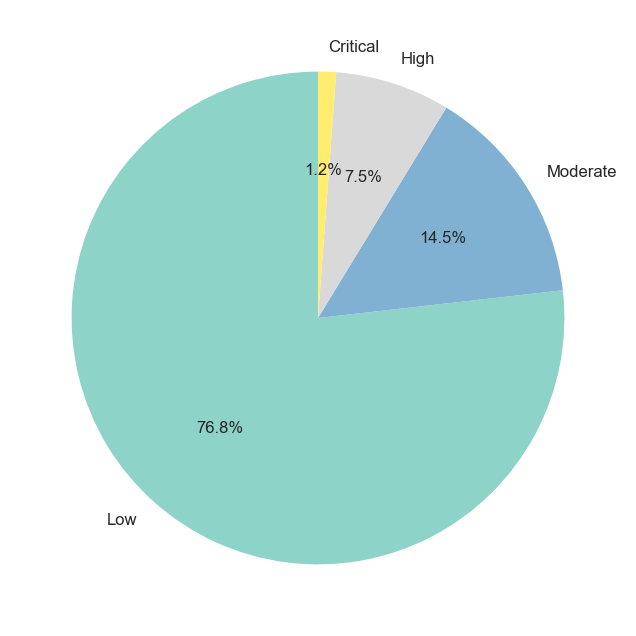

In [13]:

# Water scarcity level distribution
# =============================================================================
scarcity_distribution = df_clean['Water Scarcity Level'].value_counts()
print("Water Scarcity Level Distribution:")
#print(scarcity_distribution)

# Create donut chart
fig, ax = plt.subplots(figsize=(10, 8))

# Create pie chart
wedges, texts, autotexts = ax.pie(
    scarcity_distribution.values, 
    labels=scarcity_distribution.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12},
    colors=plt.cm.Set3(np.linspace(0, 1, len(scarcity_distribution)))  # Optional color scheme
)

In [14]:
#Top 10 countries by total water consumption (2025)
# =============================================================================

top_consumers_2025 = df_clean[df_clean['Year'] == 2025].nlargest(10, 'Total Water Consumption (Billion m3)')
print("Top 10 Water Consumers in 2025:")
top_consumers_2025[['Country', 'Total Water Consumption (Billion m3)']]

Top 10 Water Consumers in 2025:


,Country,Total Water Consumption (Billion m3)
25,China,766.41
51,India,681.25
77,USA,598.43
155,Brazil,373.77
233,Russia,339.05
103,Indonesia,238.61
3275,Mauritania,114.14
1975,Rwanda,107.27
3041,Slovakia,106.69
2417,United Arab Emirates,106.68


#### Correlation analysis

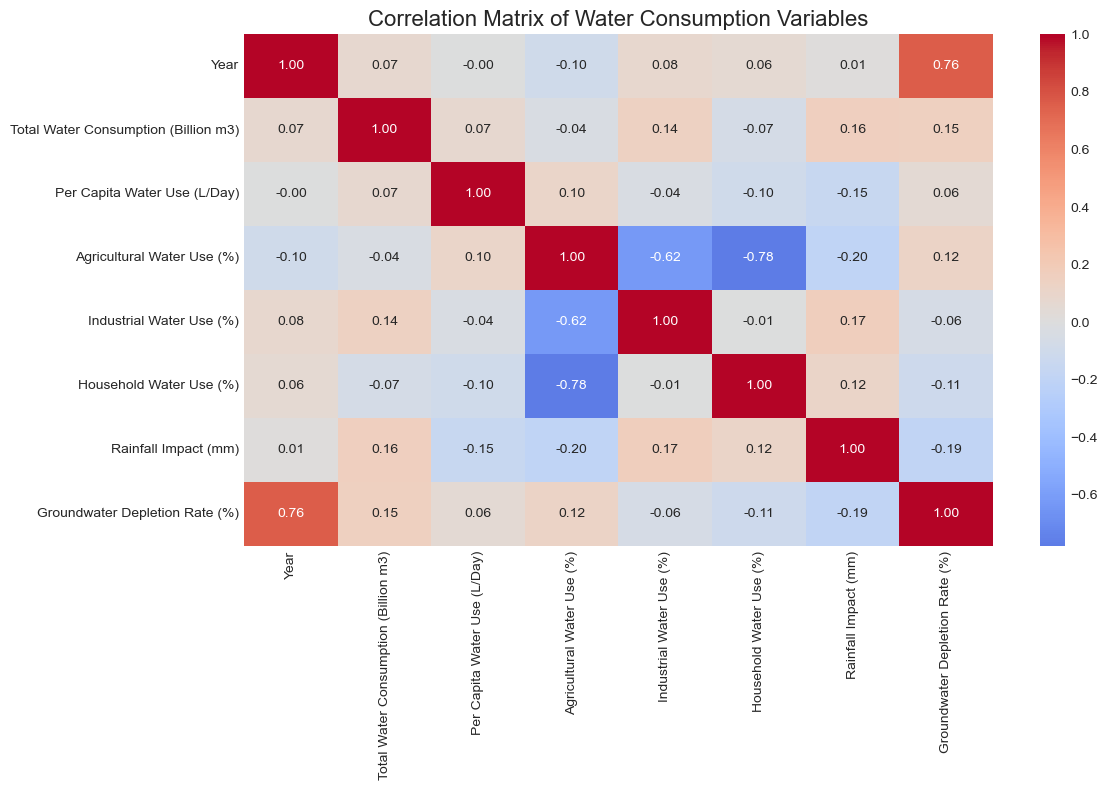

In [15]:
#Correlation analysis
# =============================================================================

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Water Consumption Variables', fontsize=16)
plt.tight_layout()
plt.show()

## Time Series Analysis

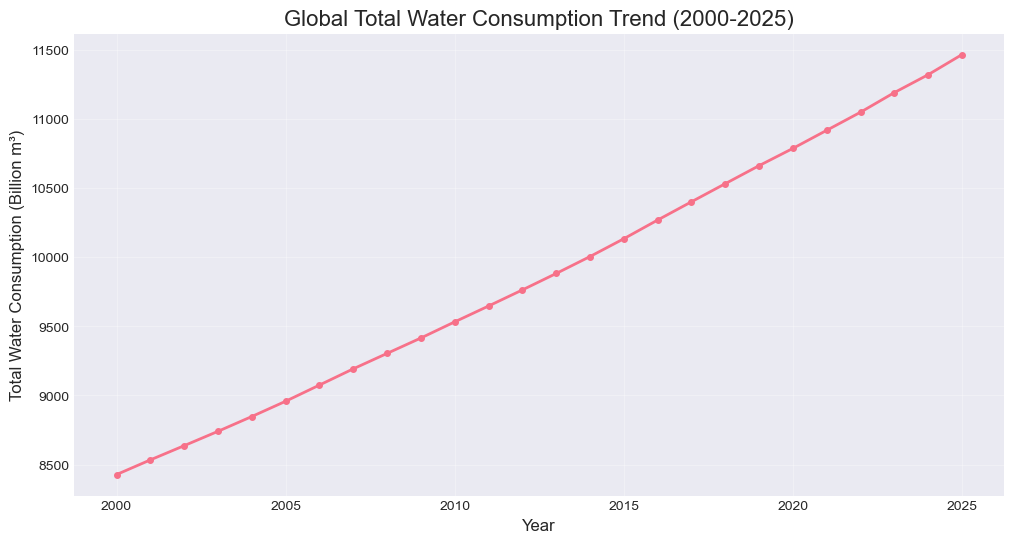

In [16]:

# Global water consumption trend
# =============================================================================
global_trend = df_clean.groupby('Year')['Total Water Consumption (Billion m3)'].sum().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(global_trend['Year'], global_trend['Total Water Consumption (Billion m3)'], 
         marker='o', linewidth=2, markersize=4)
plt.title('Global Total Water Consumption Trend (2000-2025)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Water Consumption (Billion m³)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Comparative Analysis

## Top 10 countries water consumption over time

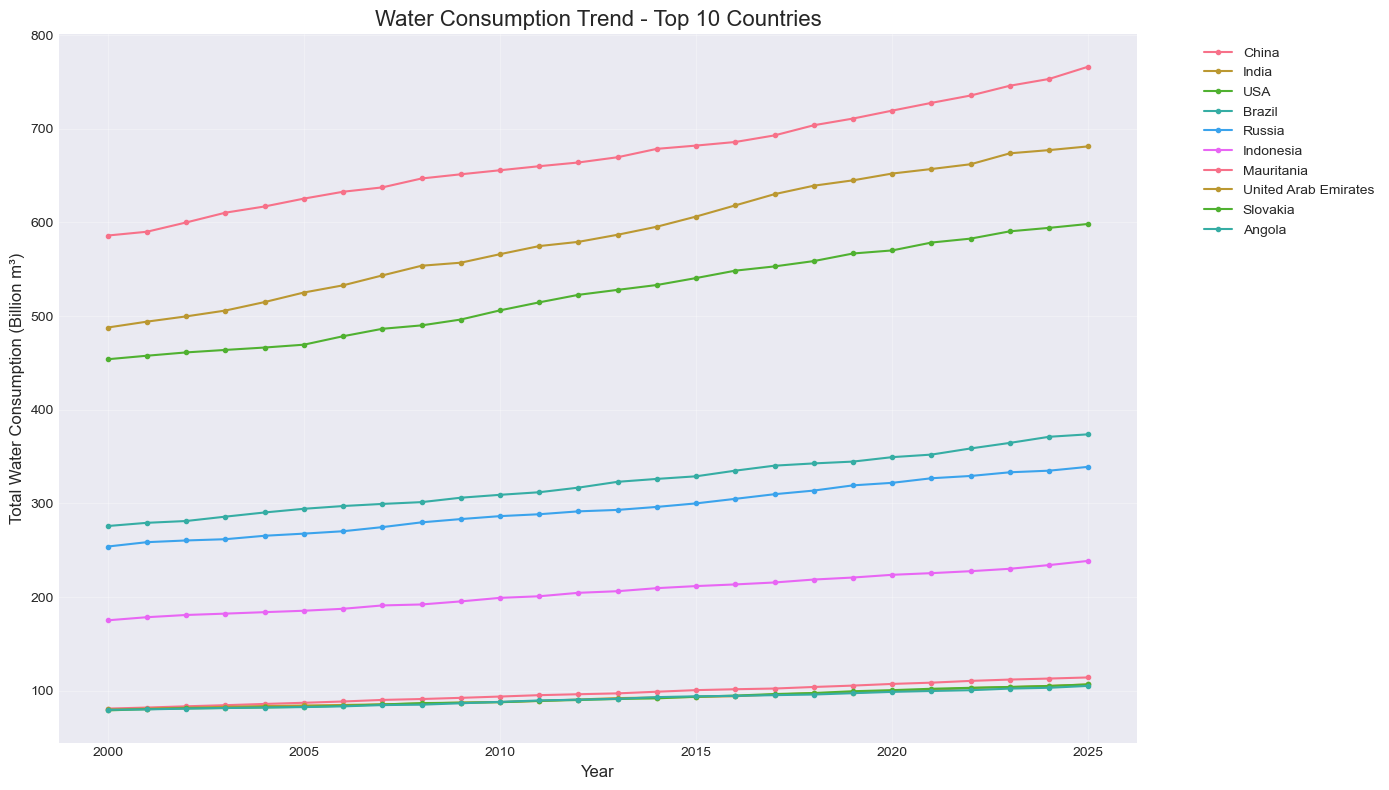

In [17]:
# top 10 countires that used more water over time
# =============================================================================

top_10_countries = df_clean.groupby('Country')['Total Water Consumption (Billion m3)'].mean().nlargest(10).index
top_10_data = df_clean[df_clean['Country'].isin(top_10_countries)]

plt.figure(figsize=(14, 8))
for country in top_10_countries:
    country_data = top_10_data[top_10_data['Country'] == country]
    plt.plot(country_data['Year'], country_data['Total Water Consumption (Billion m3)'], 
             marker='.', linewidth=1.5, label=country)

plt.title('Water Consumption Trend - Top 10 Countries', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Water Consumption (Billion m³)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() 

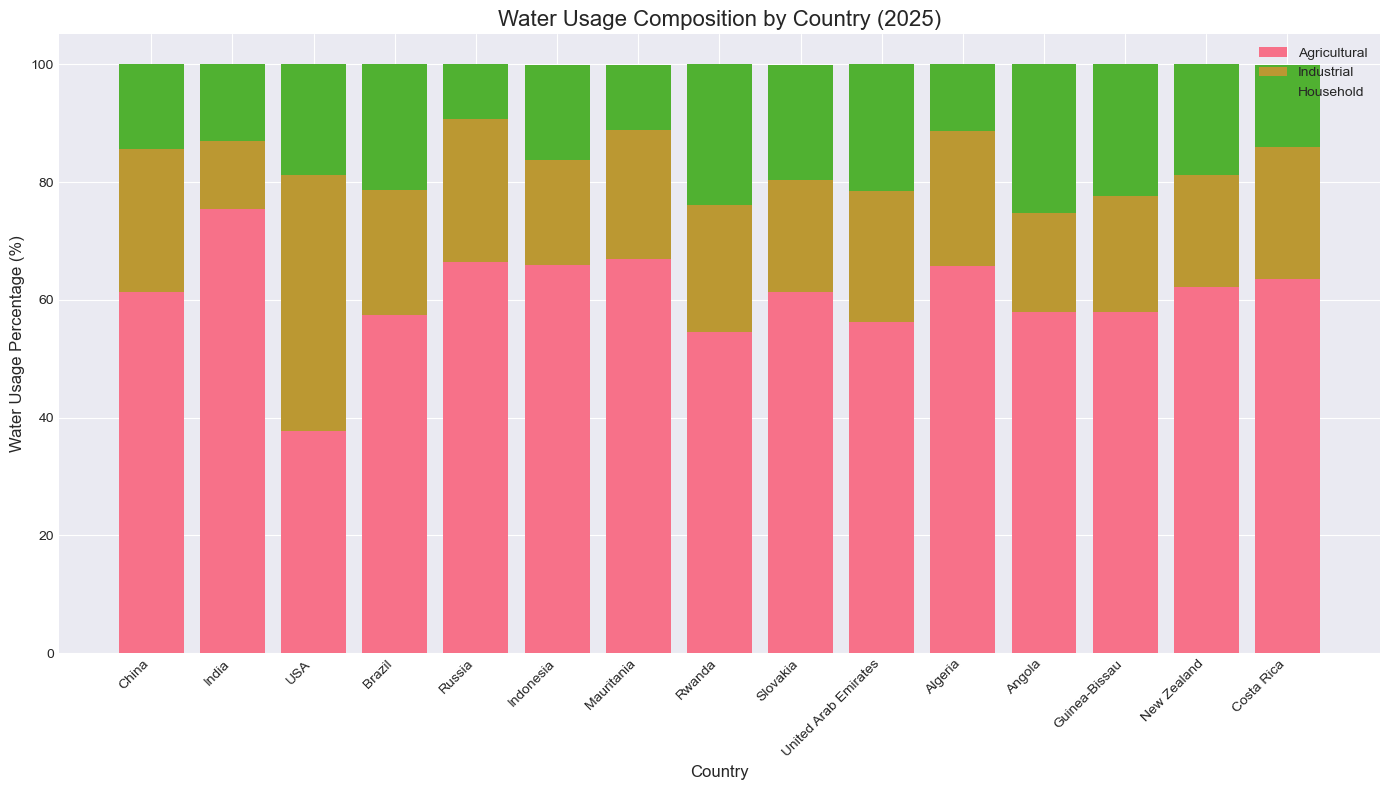

In [18]:
# Water usage composition by country (2025)
# =============================================================================
usage_2025 = df_clean[df_clean['Year'] == 2025].copy()
usage_2025['Total'] = usage_2025['Agricultural Water Use (%)'] + \
                      usage_2025['Industrial Water Use (%)'] + \
                      usage_2025['Household Water Use (%)']

# Select top 15 countries by total consumption
top_15_2025 = usage_2025.nlargest(15, 'Total Water Consumption (Billion m3)')

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))
x = range(len(top_15_2025))

ax.bar(x, top_15_2025['Agricultural Water Use (%)'], label='Agricultural', bottom=0)
ax.bar(x, top_15_2025['Industrial Water Use (%)'], label='Industrial', 
        bottom=top_15_2025['Agricultural Water Use (%)'])
ax.bar(x, top_15_2025['Household Water Use (%)'], label='Household',
       bottom=top_15_2025['Agricultural Water Use (%)'] + top_15_2025['Industrial Water Use (%)'])

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Water Usage Percentage (%)', fontsize=12)
ax.set_title('Water Usage Composition by Country (2025)', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(top_15_2025['Country'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()


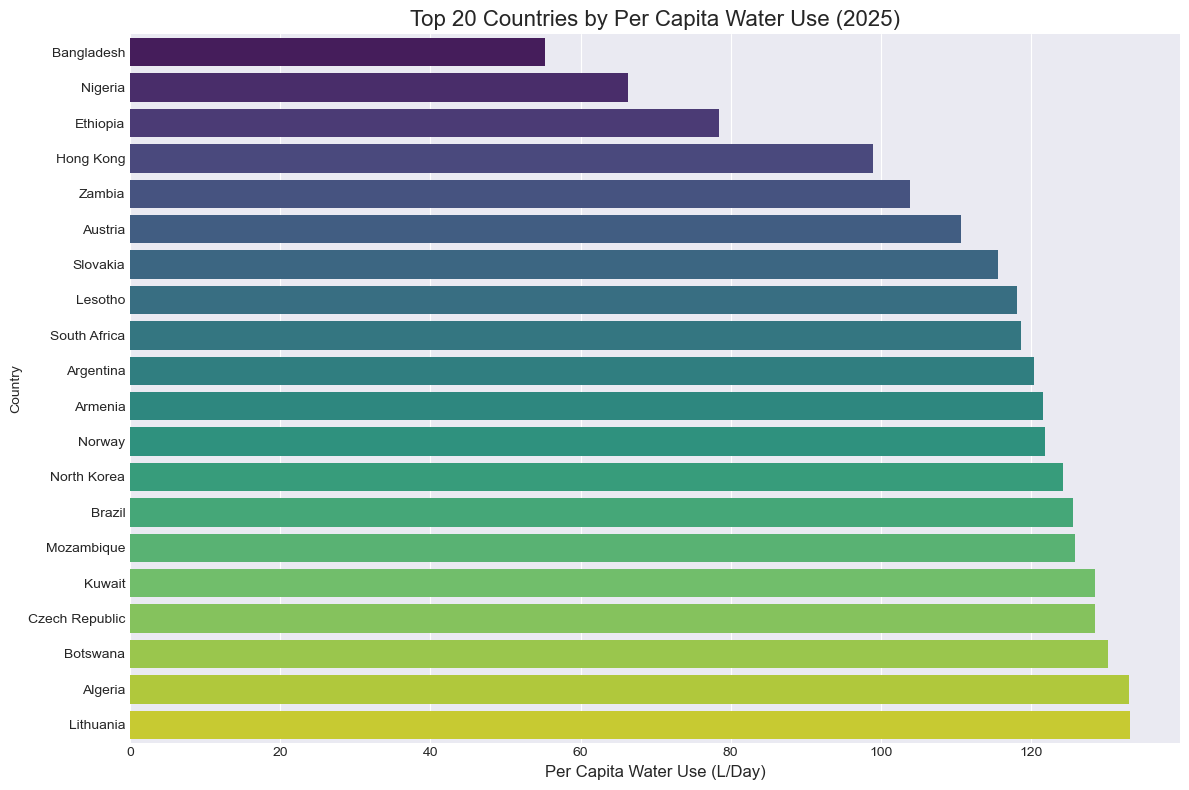

In [19]:

#Per capita water use comparison
# =============================================================================
plt.figure(figsize=(12, 8))
top_20_per_capita = df_clean[df_clean['Year'] == 2025].nsmallest(20, 'Per Capita Water Use (L/Day)')

sns.barplot(data=top_20_per_capita, y='Country', x='Per Capita Water Use (L/Day)', palette='viridis')
plt.title('Top 20 Countries by Per Capita Water Use (2025)',fontsize=16)
plt.xlabel('Per Capita Water Use (L/Day)', fontsize=12)
plt.tight_layout()
plt.show()

# Groundwater Analysis

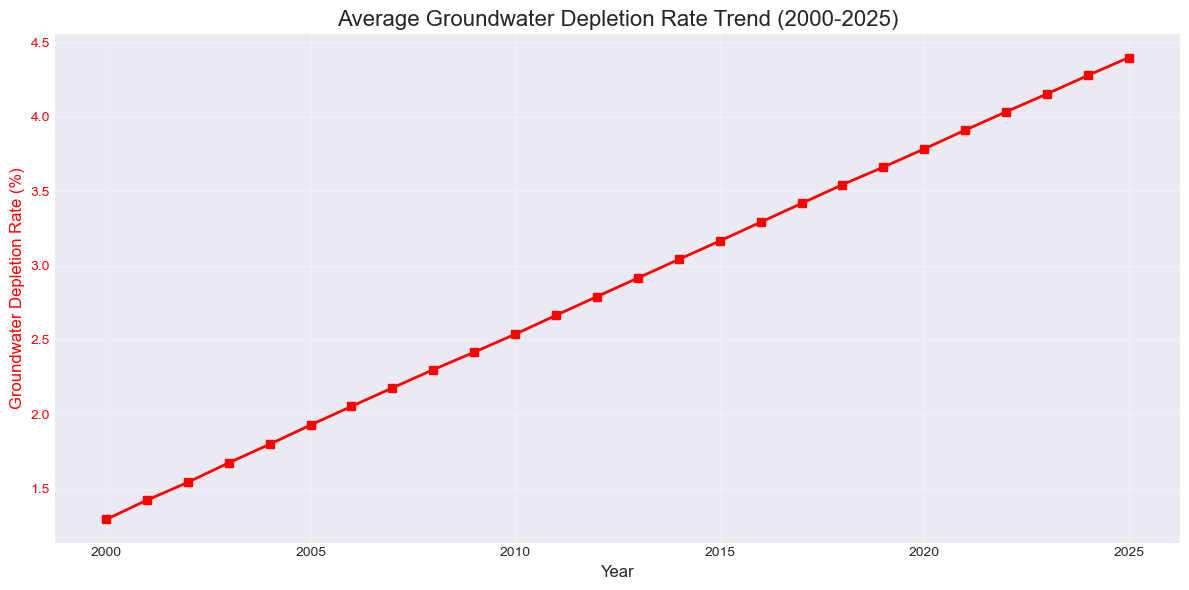

In [20]:
# Groundwater depletion trend
# =============================================================================
groundwater_trend = df_clean.groupby('Year')['Groundwater Depletion Rate (%)'].mean().reset_index()
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(groundwater_trend['Year'], groundwater_trend['Groundwater Depletion Rate (%)'], 
         color='red', marker='s', linewidth=2, label='Average Depletion Rate')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Groundwater Depletion Rate (%)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')
plt.title('Average Groundwater Depletion Rate Trend (2000-2025)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Average ground water depletion per country per year


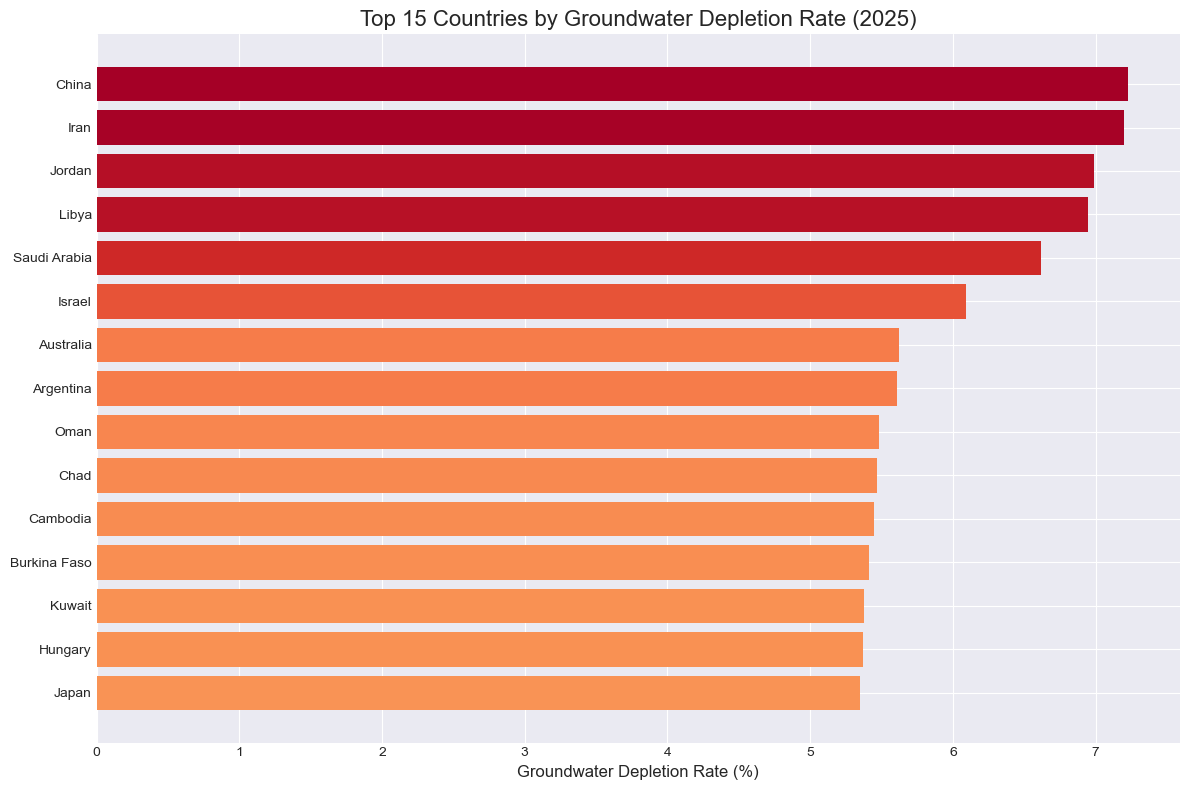

In [21]:
#Countries with highest groundwater depletion (2025)
# =============================================================================
top_depletion = df_clean[df_clean['Year'] == 2025].nlargest(15, 'Groundwater Depletion Rate (%)')

plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(top_depletion['Groundwater Depletion Rate (%)'] / top_depletion['Groundwater Depletion Rate (%)'].max())
plt.barh(top_depletion['Country'], top_depletion['Groundwater Depletion Rate (%)'], color=colors)
plt.xlabel('Groundwater Depletion Rate (%)', fontsize=12)
plt.title('Top 15 Countries by Groundwater Depletion Rate (2025)', fontsize=16)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Rainfall vs. Water Scarcity Analysis
Objective: To determine if higher rainfall levels correlate with lower water scarcity across the studied regions.

Key Interpretation Guide:

The Box: Represents the Interquartile Range (IQR). 50% of the data falls here.

The Line: The median rainfall impact for that scarcity level.

Outliers: Points beyond the whiskers indicate regions with anomalous weather patterns.


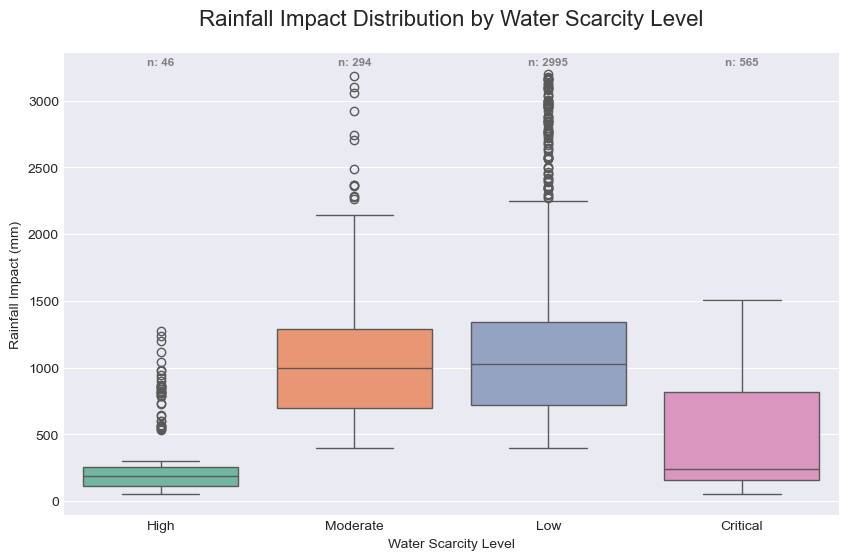

,count,mean,std,min,25%,50%,75%,max
Water Scarcity Level,,,,,,,,
Critical,46.000000,504.480000,486.120000,54.400000,155.620000,241.700000,820.380000,1507.100000
High,294.000000,253.380000,236.200000,51.900000,113.880000,187.850000,258.450000,1273.800000
Low,2995.000000,1073.370000,477.070000,400.400000,721.050000,1026.500000,1341.150000,3197.700000
Moderate,565.000000,1030.570000,430.700000,401.200000,698.300000,997.400000,1291.500000,3186.500000


In [22]:
# =============================================================================
# Rainfall Impact Distribution by Water Scarcity Level graph
# =============================================================================
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df_clean, x='Water Scarcity Level', y='Rainfall Impact (mm)', palette='Set2')

# Calculate number of observations per group & their median position
nobs = df_clean.groupby("Water Scarcity Level")['Rainfall Impact (mm)'].count().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]

# Add 'n' labels to the plot
pos = range(len(nobs))
for tick, label in zip(pos, ax.get_xticklabels()):
    ax.text(pos[tick], df_clean['Rainfall Impact (mm)'].max() * 1.02, nobs[tick],
            horizontalalignment='center', size='small', color='grey', weight='semibold')

plt.title('Rainfall Impact Distribution by Water Scarcity Level', fontsize=16, pad=20)
plt.show()

stats_summary = df_clean.groupby('Water Scarcity Level')['Rainfall Impact (mm)'].describe().round(2)
# Display with a nice caption and styling
stats_summary.style.set_caption("Rainfall Statistical Summary per Scarcity Tier") \
    .background_gradient(subset=['mean', '50%'], cmap='Blues')


### Correlation between Rainfall and Groundwater Depletion

In [23]:
#A bbuble graph that shows relationship between Rainfall and Groundwater Depletion
# =============================================================================
import plotly.express as px

fig = px.scatter(df_clean, 
                 x='Rainfall Impact (mm)', 
                 y='Groundwater Depletion Rate (%)',
                 color='Water Scarcity Level',
                 size='Total Water Consumption (Billion m3)', # Use size for a 3rd dimension
                 hover_name='Country',
                 trendline="ols", # Adds the mathematical trend line markup
                 title='Interactive Analysis: Rainfall vs. Groundwater Depletion',
                 labels={'Rainfall Impact (mm)': 'Rainfall (mm)', 
                         'Groundwater Depletion Rate (%)': 'Depletion (%)'},
                 template='plotly_white')

fig.show()

# Statistical Analysis


In [24]:

# Water Resources Statistics by Scarcity Level
# =============================================================================
# Calculate summary statistics by water scarcity level with detailed comments
scarcity_stats = df_clean.groupby('Water Scarcity Level').agg({
    'Total Water Consumption (Billion m3)': ['mean', 'std', 'count'],
    'Per Capita Water Use (L/Day)': 'mean',
    'Groundwater Depletion Rate (%)': 'mean', 
    'Rainfall Impact (mm)': 'mean'
}).round(2)

# Create more readable column names
scarcity_stats.columns = [
    'Avg Consumption (Billion m³)', 'Consumption Std Dev', 'Sample Count',
    'Avg Per Capita Use (L/Day)', 'Avg Depletion Rate (%)', 'Avg Rainfall Impact (mm)'
]

# Apply professional styling for better presentation
display_stats = scarcity_stats.style \
    .set_caption("🌍 Water Resources Statistics by Scarcity Level") \
    .format(precision=2) \
    .highlight_max(subset=['Avg Consumption (Billion m³)', 'Avg Depletion Rate (%)'], color='lightcoral') \
    .highlight_min(subset=['Avg Rainfall Impact (mm)'], color='lightblue') \
    .bar(subset=['Sample Count'], color='lightgreen', width=50)

print("Enhanced Water Scarcity Statistics:")
display_stats


Enhanced Water Scarcity Statistics:


,Avg Consumption (Billion m³),Consumption Std Dev,Sample Count,Avg Per Capita Use (L/Day),Avg Depletion Rate (%),Avg Rainfall Impact (mm)
Water Scarcity Level,,,,,,
Critical,38.50,13.71,46,272.68,4.56,504.48
High,124.53,196.26,294,267.05,4.21,253.38
Low,53.51,42.73,2995,226.65,2.42,1073.37
Moderate,102.69,134.17,565,242.34,4.31,1030.57


In [25]:
# Rainfall Statistical Summary per Scarcity Tier
# =============================================================================
stats_summary = df_clean.groupby('Water Scarcity Level')['Rainfall Impact (mm)'].describe().round(2)

# Create styled output with precise decimal formatting
styled_summary = stats_summary.style \
    .set_caption("Rainfall Statistical Summary per Scarcity Tier") \
    .background_gradient(subset=['mean', '50%'], cmap='Blues') \
    .format("{:.2f}")  # Alternative: format all numbers to exactly 2 decimal places

styled_summary


,count,mean,std,min,25%,50%,75%,max
Water Scarcity Level,,,,,,,,
Critical,46.00,504.48,486.12,54.40,155.62,241.70,820.38,1507.10
High,294.00,253.38,236.20,51.90,113.88,187.85,258.45,1273.80
Low,2995.00,1073.37,477.07,400.40,721.05,1026.50,1341.15,3197.70
Moderate,565.00,1030.57,430.70,401.20,698.30,997.40,1291.50,3186.50


In [26]:
## A more "Pandas-native" way to get the first and last values
# =============================================================================

growth_rates = df_clean.groupby('Country')['Total Water Consumption (Billion m3)'].agg(['first', 'last'])
growth_rates['Growth Rate %'] = ((growth_rates['last'] - growth_rates['first']) / growth_rates['first'] * 100).round(2)

In [27]:
# Create a gradient heatmap on your growth_rates dataframe
# =============================================================================

styled_growth = growth_rates.head(10).style.background_gradient(cmap='YlOrRd') \
    .format({"Growth Rate (2000-2025) %": "{:.2f}%"}) \
    .set_caption("Top 10 Water Consumption Growth (2000-2025)") \
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold')]}])

styled_growth

,first,last,Growth Rate %
Country,,,
Afghanistan,57.480000,79.270000,37.910000
Albania,61.170000,83.170000,35.970000
Algeria,74.940000,105.830000,41.220000
Angola,79.580000,105.120000,32.090000
Argentina,14.490000,19.760000,36.370000
Armenia,11.500000,15.400000,33.910000
Australia,19.080000,25.860000,35.530000
Austria,16.930000,22.590000,33.430000
Azerbaijan,44.210000,58.020000,31.240000


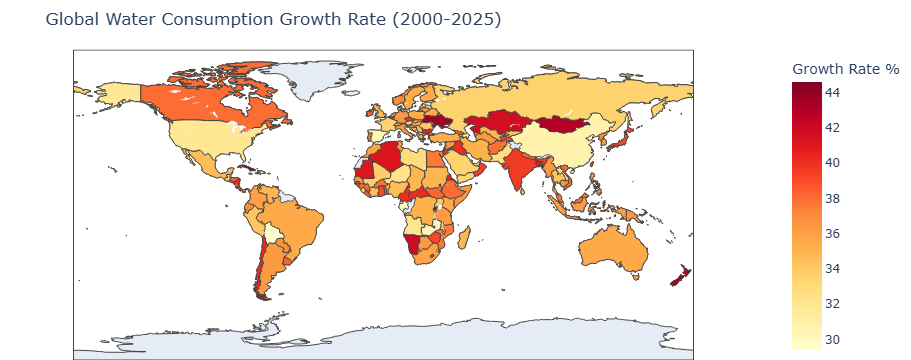

In [28]:
# Global Water Consumption Growth Rate (2000-2025
# =============================================================================
import plotly.express as px
import pandas as pd
# Re-index to get Country as a column
map_data = growth_rates.reset_index()

fig = px.choropleth(map_data, 
                    locations="Country", 
                    locationmode='country names',
                    color="Growth Rate %",
                    hover_name="Country",
                    color_continuous_scale=px.colors.sequential.YlOrRd,
                    title="Global Water Consumption Growth Rate (2000-2025)")

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

## Final Insights Dashboard

Analysis results saved to CSV files!


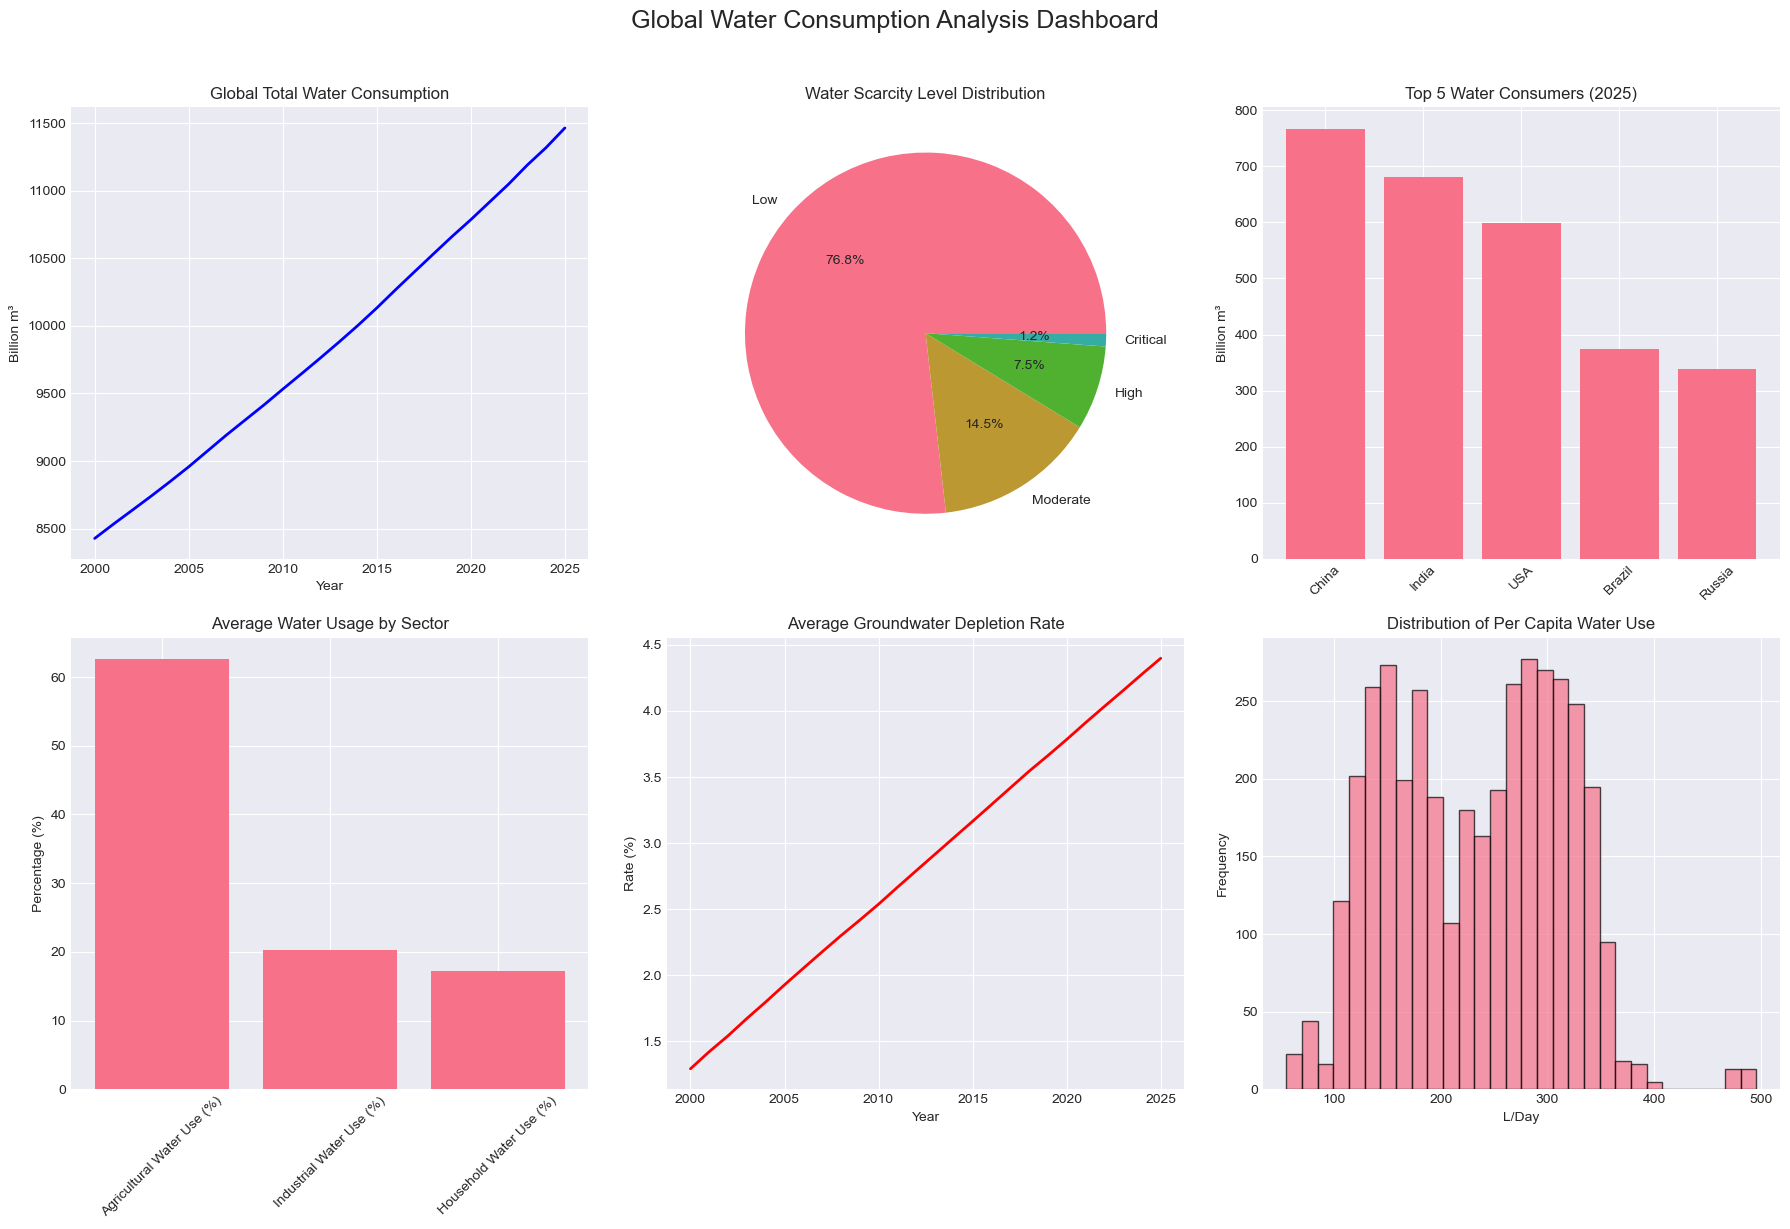

In [29]:
# Comprehensive dashboard for all the statistical finding
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Global Water Consumption Analysis Dashboard', fontsize=18, y=1.02)

# Plot 1: Total consumption by year
ax1 = axes[0, 0]
yearly_total = df_clean.groupby('Year')['Total Water Consumption (Billion m3)'].sum()
ax1.plot(yearly_total.index, yearly_total.values, 'b-', linewidth=2)
ax1.set_title('Global Total Water Consumption')
ax1.set_xlabel('Year')
ax1.set_ylabel('Billion m³')

# Plot 2: Water scarcity distribution
ax2 = axes[0, 1]
scarcity_counts = df_clean['Water Scarcity Level'].value_counts()
ax2.pie(scarcity_counts.values, labels=scarcity_counts.index, autopct='%1.1f%%')
ax2.set_title('Water Scarcity Level Distribution')
top_consumers_by_year = df_clean.groupby('Year').apply(
    lambda x: x.nlargest(3, 'Total Water Consumption (Billion m3)')[['Country', 'Total Water Consumption (Billion m3)']]
).reset_index(drop=True)
top_consumers_by_year.to_csv('top_consumers_by_year.csv', index=False)
# Summary statistics
summary_stats = df_clean.groupby('Country').agg({
    'Total Water Consumption (Billion m3)': ['mean', 'std', 'min', 'max'],
    'Groundwater Depletion Rate (%)': 'mean',
    'Per Capita Water Use (L/Day)': 'mean'
}).round(2)
summary_stats.to_csv('country_summary_stats.csv')
print("Analysis results saved to CSV files!")

# Plot 3: Top 5 countries by consumption (2025)
ax3 = axes[0, 2]
top_5_2025 = df_clean[df_clean['Year'] == 2025].nlargest(5, 'Total Water Consumption (Billion m3)')
ax3.bar(top_5_2025['Country'], top_5_2025['Total Water Consumption (Billion m3)'])
ax3.set_title('Top 5 Water Consumers (2025)')
ax3.set_ylabel('Billion m³')
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Average water usage by sector
ax4 = axes[1, 0]
sector_means = df_clean[['Agricultural Water Use (%)', 'Industrial Water Use (%)', 
                         'Household Water Use (%)']].mean()
ax4.bar(sector_means.index, sector_means.values)
ax4.set_title('Average Water Usage by Sector')
ax4.set_ylabel('Percentage (%)')
ax4.tick_params(axis='x', rotation=45)

# Plot 5: Groundwater depletion trend
ax5 = axes[1, 1]
gw_trend = df_clean.groupby('Year')['Groundwater Depletion Rate (%)'].mean()
ax5.plot(gw_trend.index, gw_trend.values, 'r-', linewidth=2)
ax5.set_title('Average Groundwater Depletion Rate')
ax5.set_xlabel('Year')
ax5.set_ylabel('Rate (%)')

# Plot 6: Per capita water use histogram
ax6 = axes[1, 2]
ax6.hist(df_clean['Per Capita Water Use (L/Day)'], bins=30, edgecolor='black', alpha=0.7)
ax6.set_title('Distribution of Per Capita Water Use')
ax6.set_xlabel('L/Day')
ax6.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# Predictive Analysis based  on Groundwater and rainfall Impact

#### Creating a risk score that will provide valuable predictive insights

In [30]:
#  Create Risk Score Calculation Function
# =============================================================================
def calculate_water_risk_score(df, year=2025):
    """
    Calculate water crisis risk score based on multiple factors
    Higher score = higher risk
    """
    # Get data for specified year
    df_year = df[df['Year'] == year].copy()
    
    # Normalize factors (0-100 scale)
    # 1. Groundwater Depletion Rate (higher = worse)
    df_year['Groundwater_Risk'] = (df_year['Groundwater Depletion Rate (%)'] - 
                                    df_year['Groundwater Depletion Rate (%)'].min()) / \
                                   (df_year['Groundwater Depletion Rate (%)'].max() - 
                                    df_year['Groundwater Depletion Rate (%)'].min()) * 100
    
    # 2. Inverse Rainfall Impact (lower rainfall = higher risk)
    df_year['Rainfall_Risk'] = (df_year['Rainfall Impact (mm)'].max() - 
                                 df_year['Rainfall Impact (mm)']) / \
                                (df_year['Rainfall Impact (mm)'].max() - 
                                 df_year['Rainfall Impact (mm)'].min()) * 100
    
    # 3. Per Capita Water Use (higher usage = higher risk)
    df_year['Usage_Risk'] = (df_year['Per Capita Water Use (L/Day)'] - 
                              df_year['Per Capita Water Use (L/Day)'].min()) / \
                             (df_year['Per Capita Water Use (L/Day)'].max() - 
                              df_year['Per Capita Water Use (L/Day)'].min()) * 100
    
    # 4. Agricultural Dependency (higher = higher risk)
    df_year['Agri_Risk'] = (df_year['Agricultural Water Use (%)'] - 
                             df_year['Agricultural Water Use (%)'].min()) / \
                            (df_year['Agricultural Water Use (%)'].max() - 
                             df_year['Agricultural Water Use (%)'].min()) * 100
    
    # 5. Historical Trend Risk (based on consumption growth 2000-2025)
    growth_rates = df[df['Country'].isin(df_year['Country'])].groupby('Country').apply(
        lambda x: ((x['Total Water Consumption (Billion m3)'].iloc[-1] - 
                    x['Total Water Consumption (Billion m3)'].iloc[0]) / 
                   x['Total Water Consumption (Billion m3)'].iloc[0]) * 100
    ).reset_index()
    growth_rates.columns = ['Country', 'Growth_Rate']
    
    df_year = df_year.merge(growth_rates, on='Country', how='left')
    df_year['Growth_Risk'] = (df_year['Growth_Rate'] - df_year['Growth_Rate'].min()) / \
                              (df_year['Growth_Rate'].max() - df_year['Growth_Rate'].min()) * 100
    
    # 6. Current Water Scarcity Level (encode as risk)
    scarcity_mapping = {'Low': 0, 'Moderate': 33, 'High': 66, 'Critical': 100}
    df_year['Scarcity_Risk'] = df_year['Water Scarcity Level'].map(scarcity_mapping)
    
    # Calculate weighted composite risk score
    weights = {
        'Groundwater_Risk': 0.25,
        'Rainfall_Risk': 0.20,
        'Usage_Risk': 0.15,
        'Agri_Risk': 0.15,
        'Growth_Risk': 0.15,
        'Scarcity_Risk': 0.10
    }
    
    df_year['Water_Crisis_Risk_Score'] = (
        weights['Groundwater_Risk'] * df_year['Groundwater_Risk'] +
        weights['Rainfall_Risk'] * df_year['Rainfall_Risk'] +
        weights['Usage_Risk'] * df_year['Usage_Risk'] +
        weights['Agri_Risk'] * df_year['Agri_Risk'] +
        weights['Growth_Risk'] * df_year['Growth_Risk'] +
        weights['Scarcity_Risk'] * df_year['Scarcity_Risk']
    ).round(2)
    
    # Add risk category
    def categorize_risk(score):
        if score >= 75:
            return 'Critical Risk'
        elif score >= 50:
            return 'High Risk'
        elif score >= 25:
            return 'Moderate Risk'
        else:
            return 'Low Risk'
    
    df_year['Risk_Category'] = df_year['Water_Crisis_Risk_Score'].apply(categorize_risk)
    
    return df_year

# Calculate risk scores for 2025
risk_scores_2025 = calculate_water_risk_score(df_clean, 2025)

# Display results
print("Water Crisis Risk Scores (2025) - Top 20 Highest Risk:")
risk_scores_2025[['Country', 'Water_Crisis_Risk_Score', 'Risk_Category', 
                  'Groundwater Depletion Rate (%)', 'Rainfall Impact (mm)']].sort_values(
    'Water_Crisis_Risk_Score', ascending=False).head(10)

Water Crisis Risk Scores (2025) - Top 20 Highest Risk:


,Country,Water_Crisis_Risk_Score,Risk_Category,Groundwater Depletion Rate (%),Rainfall Impact (mm)
87,Jordan,81.00,Critical Risk,6.99,173.3
17,Iran,78.47,Critical Risk,7.20,223.2
99,Israel,78.30,Critical Risk,6.09,181.3
107,Libya,75.15,Critical Risk,6.95,273.0
40,Saudi Arabia,73.11,High Risk,6.62,266.3
140,Namibia,72.34,High Risk,5.09,103.2
54,Australia,70.29,High Risk,5.62,293.1
13,Egypt,68.85,High Risk,4.28,131.7
35,Iraq,68.58,High Risk,5.12,269.3
82,Cuba,62.02,High Risk,4.84,718.5


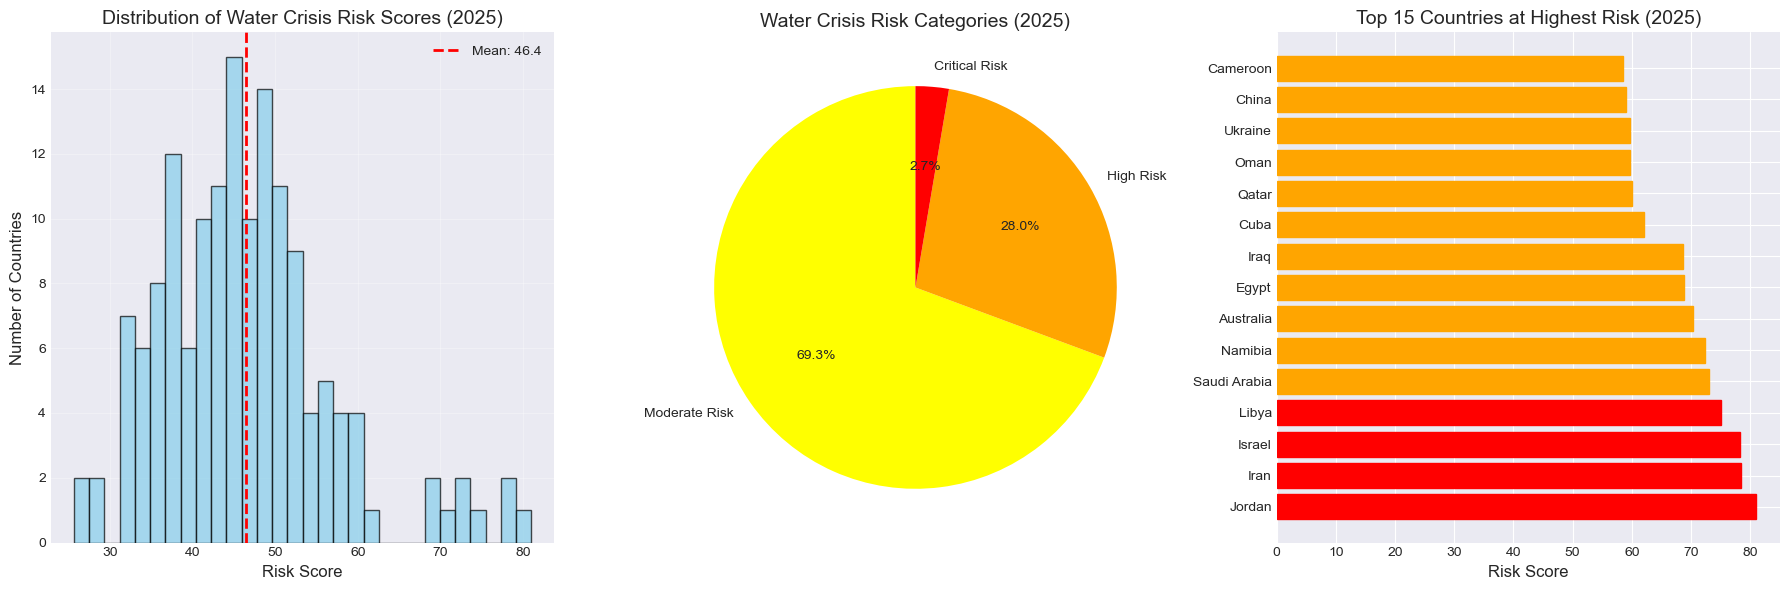

In [31]:
#  Risk Score Distribution

# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Risk Score Distribution
ax1 = axes[0]
ax1.hist(risk_scores_2025['Water_Crisis_Risk_Score'], bins=30, edgecolor='black', 
         color='skyblue', alpha=0.7)
ax1.axvline(risk_scores_2025['Water_Crisis_Risk_Score'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f"Mean: {risk_scores_2025['Water_Crisis_Risk_Score'].mean():.1f}")
ax1.set_xlabel('Risk Score', fontsize=12)
ax1.set_ylabel('Number of Countries', fontsize=12)
ax1.set_title('Distribution of Water Crisis Risk Scores (2025)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Risk Categories Pie Chart
ax2 = axes[1]
category_counts = risk_scores_2025['Risk_Category'].value_counts()
colors = {'Critical Risk': 'red', 'High Risk': 'orange', 
          'Moderate Risk': 'yellow', 'Low Risk': 'green'}
pie_colors = [colors[cat] for cat in category_counts.index]
ax2.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
        colors=pie_colors, startangle=90)
ax2.set_title('Water Crisis Risk Categories (2025)', fontsize=14)

# Plot 3: Top 15 Highest Risk Countries
ax3 = axes[2]
top_15_risk = risk_scores_2025.nlargest(15, 'Water_Crisis_Risk_Score')
bars = ax3.barh(range(len(top_15_risk)), top_15_risk['Water_Crisis_Risk_Score'].values)
ax3.set_yticks(range(len(top_15_risk)))
ax3.set_yticklabels(top_15_risk['Country'].values)
ax3.set_xlabel('Risk Score', fontsize=12)
ax3.set_title('Top 15 Countries at Highest Risk (2025)', fontsize=14)
#ax3.gca().invert_yaxis()

# Color bars by risk level
for i, (_, row) in enumerate(top_15_risk.iterrows()):
    if row['Risk_Category'] == 'Critical Risk':
        bars[i].set_color('red')
    elif row['Risk_Category'] == 'High Risk':
        bars[i].set_color('orange')
    else:
        bars[i].set_color('yellow')

plt.tight_layout()
plt.show()

### Risk score calculation function

##### Current risk distribution visualization,
##### Simple 2030 predictions using linear trends,
##### Top risk countries and fastest deteriorating,
##### Clean bar chart visualization.

In [32]:
#Firstly we Define calculate_risk  and then  calculate the risk 
# =============================================================================
def calculate_risk(row):
    score = 0
    # Groundwater depletion (0-40)
    dep = row['Groundwater Depletion Rate (%)']
    if dep >= 7: score += 40
    elif dep >= 5: score += 30
    elif dep >= 3: score += 20
    elif dep >= 1: score += 10
    
    # Rainfall impact (0-30)
    rain = row['Rainfall Impact (mm)']
    if rain < 200: score += 30
    elif rain < 500: score += 20
    elif rain < 1000: score += 10
    
    # Water scarcity level (0-30)
    scarcity_map = {'Critical':30, 'High':20, 'Moderate':10, 'Low':0}
    score += scarcity_map.get(row['Water Scarcity Level'], 0)
    
    return score

In [33]:
# Simple 2030 prediction
countries = df['Country'].unique()
df_clean = []

for country in countries:
    country_data = df[df['Country']==country].sort_values('Year')
    latest = country_data[country_data['Year']==2025].iloc[0]
    
    # 1. Simple linear trend (using polyfit)
    dep_trend = np.polyfit(country_data['Year'], country_data['Groundwater Depletion Rate (%)'], 1)[0]
    rain_trend = np.polyfit(country_data['Year'], country_data['Rainfall Impact (mm)'], 1)[0]
    
    # 2. Predict 2030 (5 years out from 2025)
    pred_dep = latest['Groundwater Depletion Rate (%)'] + dep_trend * 5
    pred_rain = max(0, latest['Rainfall Impact (mm)'] + rain_trend * 5)
    
    # 3. Calculate Risk for 2030
    temp_row_2030 = pd.Series({
        'Groundwater Depletion Rate (%)': pred_dep,
        'Rainfall Impact (mm)': pred_rain,
        'Water Scarcity Level': latest['Water Scarcity Level'] 
    })
    pred_risk_2030 = calculate_risk(temp_row_2030)
    
    # 4. Calculate Risk for 2025 (Ensuring the 'Score' exists)
    # If 'Score' isn't in df, calculate it now:
    risk_2025 = calculate_risk(latest) 

    df_clean.append({
        'Country': country,
        'Risk_2025': risk_2025,
        'Risk_2030': pred_risk_2030,
        'Change': pred_risk_2030 - risk_2025
    })

# Create DataFrame from the list 'df_clean'
pred_df = pd.DataFrame(df_clean).sort_values('Risk_2030', ascending=False)

In [34]:
# Create a styled view for the Top 10 High Risk Countries
#================================================================================
styled_risk = pred_df[['Country', 'Risk_2030', 'Change']].head(10).style \
    .background_gradient(subset=['Risk_2030'], cmap='Reds') \
    .bar(subset=['Change'], color='#f07167') \
    .format({'Risk_2030': '{:.2f}', 'Change': '+{:.2f}%'}) \
    .set_caption("⚠️ Top 10 Countries at Highest Risk by 2030")

# Display the styled table
display(styled_risk)

# Create a styled view for the Fastest Deteriorating
styled_deterioration = pred_df.nlargest(5, 'Change')[['Country', 'Change', 'Risk_2030']].style \
    .background_gradient(subset=['Change'], cmap='Oranges') \
    .format({'Risk_2030': '{:.2f}', 'Change': '+{:.2f}%'}) \
    .set_caption("📉 Fastest Deteriorating (2025-2030)")

display(styled_deterioration)

,Country,Risk_2030,Change
107,Libya,90.00,+10.00%
87,Jordan,90.00,+10.00%
17,Iran,80.00,+0.00%
13,Egypt,80.00,+0.00%
140,Namibia,80.00,+0.00%
137,Qatar,80.00,+10.00%
40,Saudi Arabia,80.00,+10.00%
99,Israel,80.00,+0.00%
127,Kuwait,70.00,+0.00%
35,Iraq,70.00,+0.00%


,Country,Change,Risk_2030
64,Zambia,+20.00%,60.00
9,Mexico,+20.00%,50.00
107,Libya,+10.00%,90.00
87,Jordan,+10.00%,90.00
137,Qatar,+10.00%,80.00


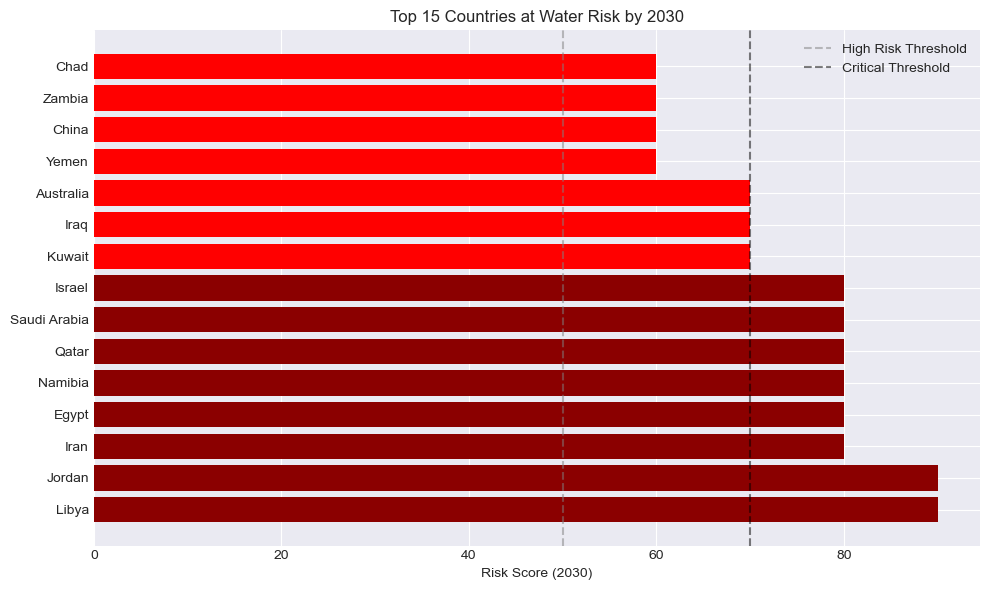

In [35]:

#Simple visualization for top 15 Coutirs with water risk by 2030
#=========================================================================
fig, ax = plt.subplots(figsize=(10, 6))
top15 = pred_df.head(15)
colors = ['darkred' if x>70 else 'red' if x>50 else 'orange' for x in top15['Risk_2030']]
ax.barh(range(len(top15)), top15['Risk_2030'], color=colors)
#ax.line(range(len(top15)), top15['Risk_2030'], color=colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Country'])
ax.set_xlabel('Risk Score (2030)')
ax.set_title('Top 15 Countries at Water Risk by 2030')
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='High Risk Threshold')
ax.axvline(x=70, color='black', linestyle='--', alpha=0.5, label='Critical Threshold')
ax.legend()
plt.tight_layout()
plt.show()

Regional Risk Analysis for 2030:
               Country_Count  Avg_Risk_Score  Max_Risk_Score  Risk_Std  \
Region                                                                   
Middle East               12           60.83              90     24.29   
Oceania                    3           46.67              70     20.82   
North America              7           40.00              50     12.91   
Asia                      16           38.75              60     11.47   
Other                     30           38.67              90     17.56   
South America             10           38.00              50     10.33   
Europe                    34           36.47              60     12.28   
Africa                    38           36.32              80     14.03   

               Critical_Risk_Count  
Region                              
Middle East                      7  
Oceania                          1  
North America                    0  
Asia                             0  
Othe

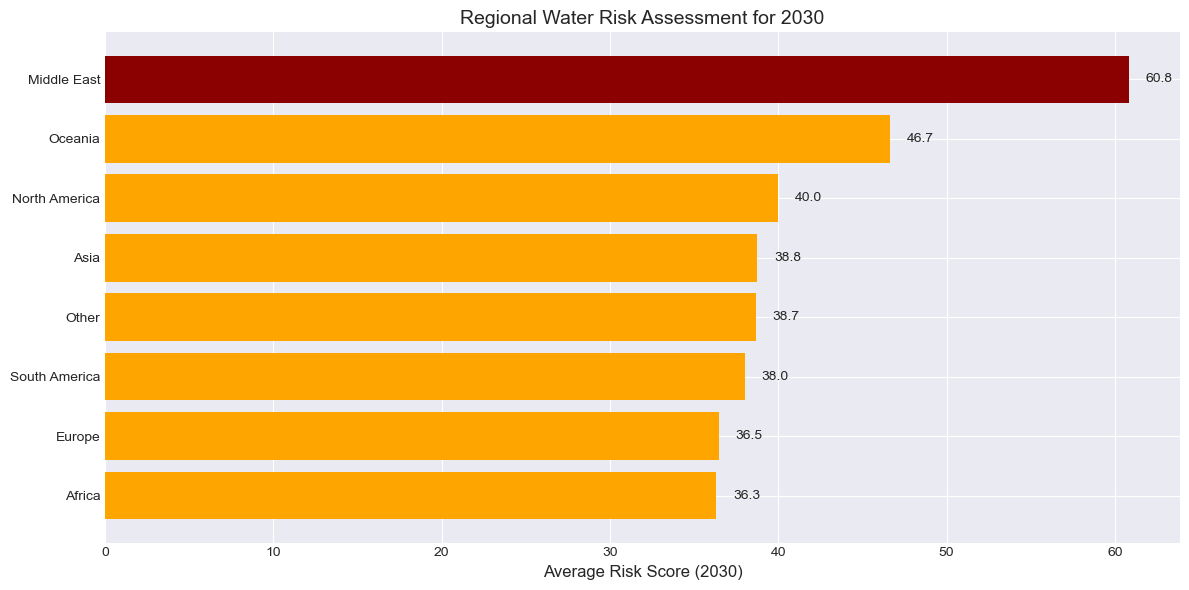

In [36]:
# Regional Risk Analysis
# Define regions (you can adjust these groupings)
# =============================================================================
regions = {
    'Asia': ['China', 'India', 'Indonesia', 'Pakistan', 'Bangladesh', 'Japan', 
             'Philippines', 'Vietnam', 'Thailand', 'Malaysia', 'South Korea', 
             'Myanmar', 'Nepal', 'Sri Lanka', 'Afghanistan', 'Cambodia'],
    'Middle East': ['Iran', 'Iraq', 'Saudi Arabia', 'Yemen', 'Syria', 'Jordan', 
                    'Israel', 'Lebanon', 'Kuwait', 'Qatar', 'Oman', 'Bahrain'],
    'Africa': ['Nigeria', 'Ethiopia', 'Egypt', 'DR Congo', 'Tanzania', 'South Africa',
               'Kenya', 'Uganda', 'Algeria', 'Sudan', 'Morocco', 'Angola', 'Ghana',
               'Mozambique', 'Madagascar', 'Cameroon', 'Niger', 'Mali', 'Burkina Faso',
               'Malawi', 'Zambia', 'Senegal', 'Chad', 'Somalia', 'Zimbabwe', 'Guinea',
               'Rwanda', 'Benin', 'Burundi', 'Tunisia', 'South Sudan', 'Liberia',
               'Mauritania', 'Eritrea', 'Gambia', 'Botswana', 'Gabon', 'Lesotho'],
    'Europe': ['Russia', 'Germany', 'United Kingdom', 'France', 'Italy', 'Spain',
               'Ukraine', 'Poland', 'Romania', 'Netherlands', 'Belgium', 'Greece',
               'Portugal', 'Sweden', 'Austria', 'Switzerland', 'Hungary', 'Belarus',
               'Czech Republic', 'Norway', 'Denmark', 'Finland', 'Ireland', 'Croatia',
               'Moldova', 'Georgia', 'Bosnia and Herzegovina', 'Albania', 'Lithuania',
               'Latvia', 'Slovenia', 'North Macedonia', 'Bulgaria', 'Serbia'],
    'North America': ['USA', 'Mexico', 'Canada', 'Cuba', 'Haiti', 'Dominican Republic',
                      'Jamaica'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Peru', 'Venezuela', 'Chile',
                      'Ecuador', 'Bolivia', 'Paraguay', 'Uruguay'],
    'Oceania': ['Australia', 'New Zealand', 'Papua New Guinea']
}

# Add region column to pred_df (not predictions_df)
def get_region(country):
    for region, countries in regions.items():
        if country in countries:
            return region
    return 'Other'

pred_df['Region'] = pred_df['Country'].apply(get_region)

# Add Risk Category column if it doesn't exist
def categorize_risk(score):
    if score >= 70:
        return 'Critical Risk'
    elif score >= 50:
        return 'High Risk'
    elif score >= 30:
        return 'Moderate Risk'
    else:
        return 'Low Risk'

pred_df['Risk_Category_2030'] = pred_df['Risk_2030'].apply(categorize_risk)

# Regional risk summary
regional_risk = pred_df.groupby('Region').agg({
    'Country': 'count',
    'Risk_2030': ['mean', 'max', 'std'],
    'Risk_Category_2030': lambda x: (x == 'Critical Risk').sum()
}).round(2)

regional_risk.columns = ['Country_Count', 'Avg_Risk_Score', 'Max_Risk_Score', 'Risk_Std', 'Critical_Risk_Count']
print("Regional Risk Analysis for 2030:")
print(regional_risk.sort_values('Avg_Risk_Score', ascending=False))

# Visualize regional risk
fig, ax = plt.subplots(figsize=(12, 6))
regional_avg = pred_df.groupby('Region')['Risk_2030'].mean().sort_values(ascending=True)

colors_reg = ['darkred' if x > 60 else 'red' if x > 50 else 'orange' if x > 35 else 'green' 
              for x in regional_avg.values]
ax.barh(regional_avg.index, regional_avg.values, color=colors_reg)
ax.set_xlabel('Average Risk Score (2030)', fontsize=12)
ax.set_title('Regional Water Risk Assessment for 2030', fontsize=14)

# Add value labels
for i, v in enumerate(regional_avg.values):
    ax.text(v + 1, i, str(round(v, 1)), va='center')

plt.tight_layout()
plt.show()

In [37]:
# =============================================================================
# First, ensure all necessary columns exist
# Calculate Risk_2030 from Risk_Score (or create it)
# =============================================================================
if 'Risk_2030' not in df.columns:
    if 'Risk_Score' in df.columns:
        df['Risk_2030'] = df['Risk_Score']
    else:
        # Create a composite risk score
        df['Risk_2030'] = (df['Groundwater Depletion Rate (%)'] * 2 + 
                           (1000 - df['Rainfall Impact (mm)']) / 10)

In [39]:

# Calculate the risk for prediction
# =============================================================================
def categorize_risk(score):
    if score >= 70:
        return 'Critical Risk'
    elif score >= 50:
        return 'High Risk'
    elif score >= 30:
        return 'Moderate Risk'
    else:
        return 'Low Risk'

pred_df['Risk_Category_2030'] = pred_df['Risk_2030'].apply(categorize_risk)

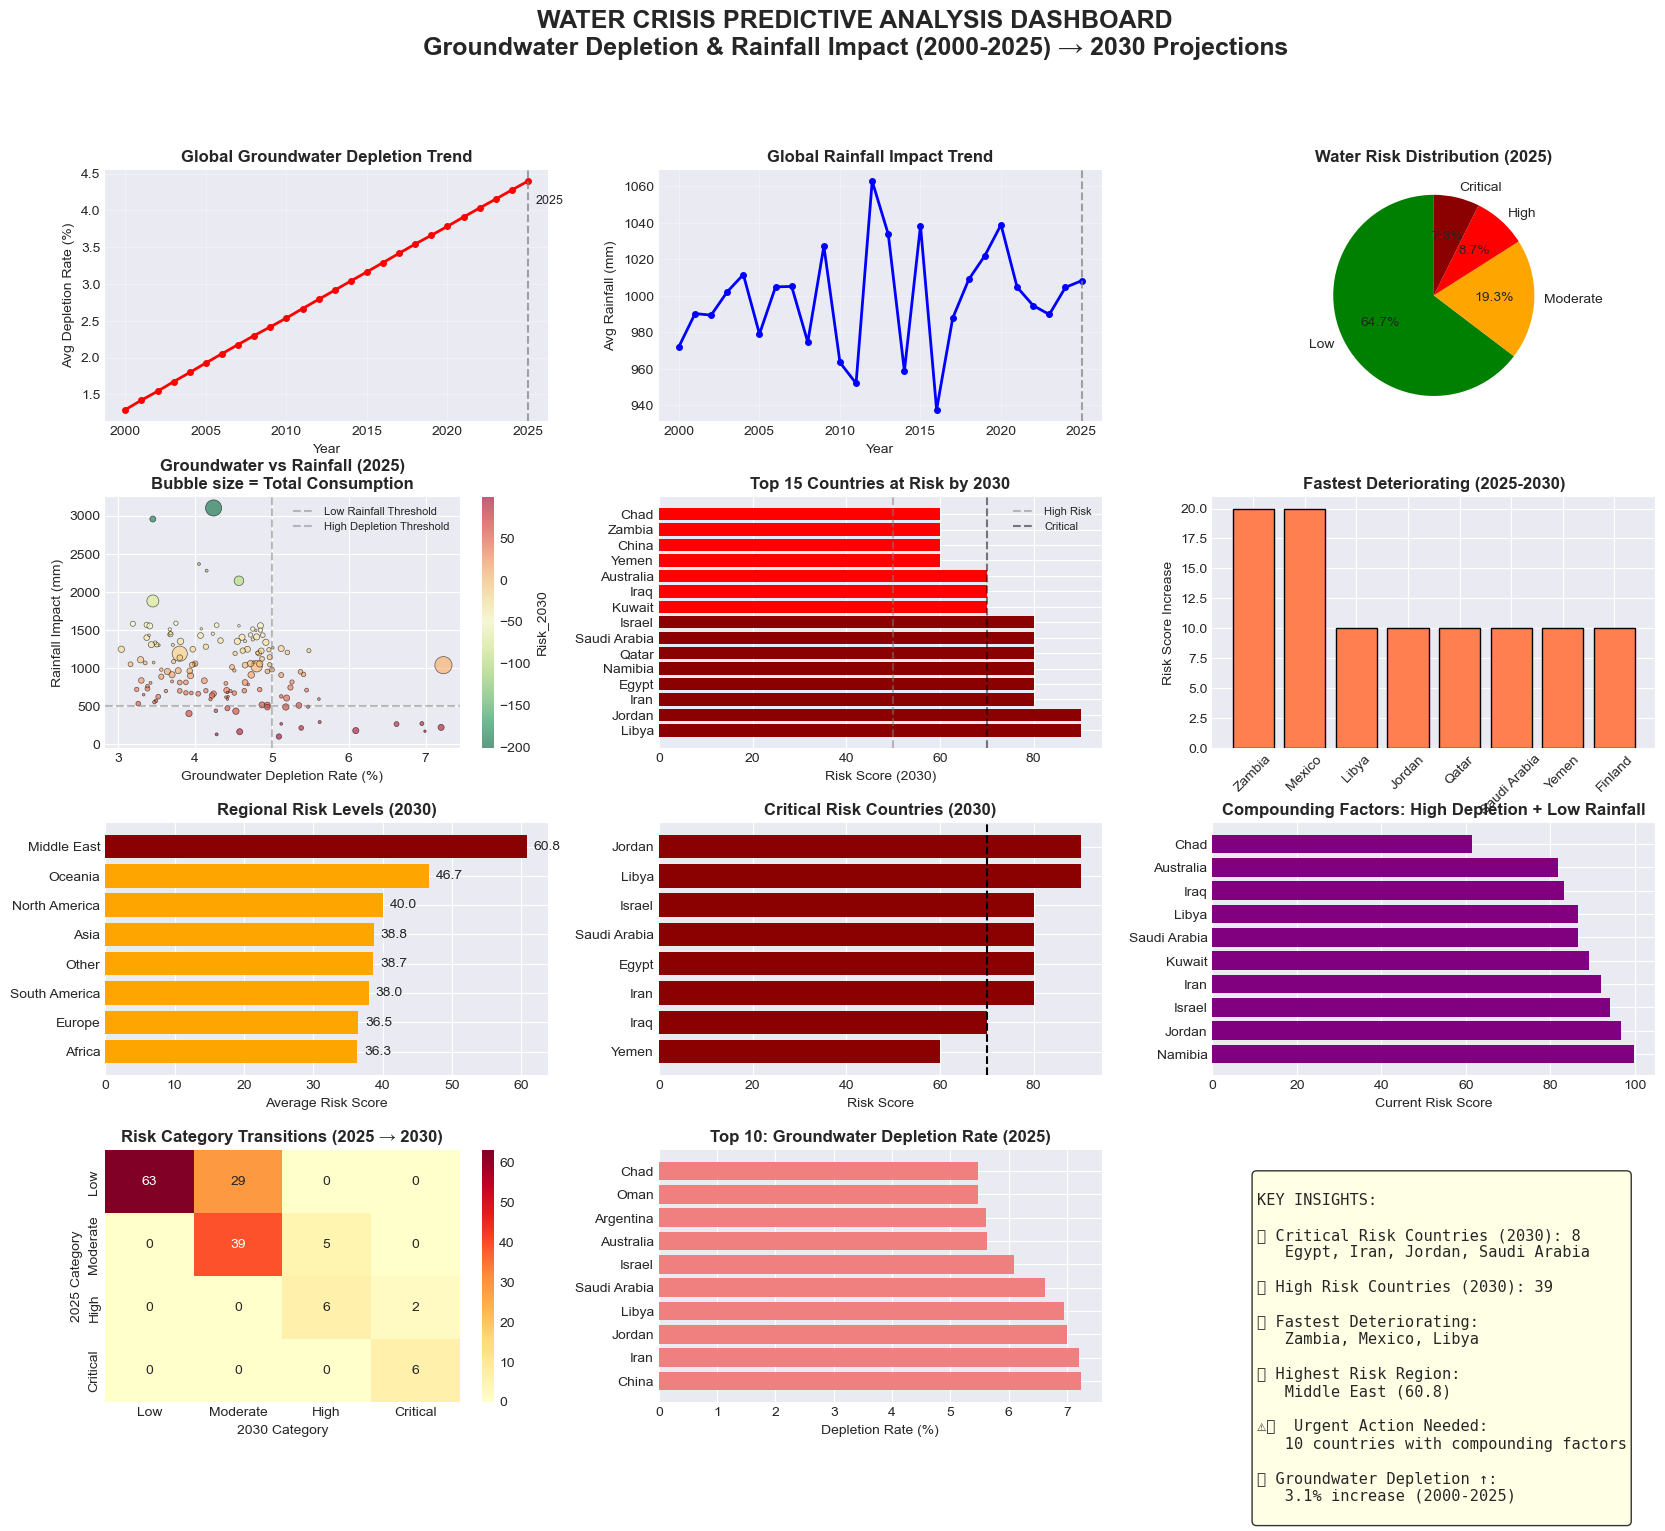

In [40]:

# DASHBOARD: Predictive Analysis - Groundwater & Rainfall Impact on Water Crisis
# =============================================================================

# First, ensure all necessary columns exist
# Add Risk_Level for current data (if not already defined)
if 'Risk_Level' not in df.columns:
    def categorize_risk_current(score):
        if score >= 70:
            return 'Critical'
        elif score >= 50:
            return 'High'
        elif score >= 30:
            return 'Moderate'
        else:
            return 'Low'
    
    df['Risk_Level'] = df['Risk_2030'].apply(categorize_risk_current)

# Create a comprehensive dashboard with all visualizations
fig = plt.figure(figsize=(20, 16))
fig.suptitle('WATER CRISIS PREDICTIVE ANALYSIS DASHBOARD\nGroundwater Depletion & Rainfall Impact (2000-2025) → 2030 Projections', 
             fontsize=18, fontweight='bold', y=0.98)

# Define grid for subplots
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.25)


# 1. Groundwater Depletion Trend 

ax1 = fig.add_subplot(gs[0, 0])
gw_trend = df.groupby('Year')['Groundwater Depletion Rate (%)'].mean()
ax1.plot(gw_trend.index, gw_trend.values, 'r-o', linewidth=2, markersize=4)
ax1.set_title('Global Groundwater Depletion Trend', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Depletion Rate (%)')
ax1.axvline(x=2025, color='gray', linestyle='--', alpha=0.7)
ax1.text(2025.5, ax1.get_ylim()[1]*0.9, '2025', fontsize=9)
ax1.grid(True, alpha=0.3)


# 2. Rainfall Impact Trend 

ax2 = fig.add_subplot(gs[0, 1])
rain_trend = df.groupby('Year')['Rainfall Impact (mm)'].mean()
ax2.plot(rain_trend.index, rain_trend.values, 'b-o', linewidth=2, markersize=4)
ax2.set_title('Global Rainfall Impact Trend', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Avg Rainfall (mm)')
ax2.axvline(x=2025, color='gray', linestyle='--', alpha=0.7)
ax2.grid(True, alpha=0.3)


# 3. Current Risk Distribution 

ax3 = fig.add_subplot(gs[0, 2])
risk_counts = df[df['Year']==2025]['Risk_Level'].value_counts()
colors_pie = {'Low':'green', 'Moderate':'orange', 'High':'red', 'Critical':'darkred'}
pie_colors = [colors_pie[x] for x in risk_counts.index]
ax3.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', 
        colors=pie_colors, startangle=90)
ax3.set_title('Water Risk Distribution (2025)', fontweight='bold')


# 4. Groundwater vs Rainfall Scatter 

ax4 = fig.add_subplot(gs[1, 0])
df_2025 = df[df['Year'] == 2025]
scatter = ax4.scatter(df_2025['Groundwater Depletion Rate (%)'], 
                      df_2025['Rainfall Impact (mm)'],
                      c=df_2025['Risk_2030'], cmap='RdYlGn_r', 
                      s=df_2025['Total Water Consumption (Billion m3)']/5,
                      alpha=0.6, edgecolors='black', linewidth=0.5)
ax4.set_xlabel('Groundwater Depletion Rate (%)')
ax4.set_ylabel('Rainfall Impact (mm)')
ax4.set_title('Groundwater vs Rainfall (2025)\nBubble size = Total Consumption', fontweight='bold')
ax4.axhline(y=500, color='gray', linestyle='--', alpha=0.5, label='Low Rainfall Threshold')
ax4.axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='High Depletion Threshold')
ax4.legend(loc='upper right', fontsize=8)
plt.colorbar(scatter, ax=ax4, label='Risk_2030')


# 5. Top 15 High Risk Countries 

ax5 = fig.add_subplot(gs[1, 1])
top_risk = pred_df.head(15)
colors_bar = ['darkred' if x>70 else 'red' if x>50 else 'orange' for x in top_risk['Risk_2030']]
bars = ax5.barh(range(len(top_risk)), top_risk['Risk_2030'], color=colors_bar)
ax5.set_yticks(range(len(top_risk)))
ax5.set_yticklabels(top_risk['Country'])
ax5.set_xlabel('Risk Score (2030)')
ax5.set_title('Top 15 Countries at Risk by 2030', fontweight='bold')
ax5.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='High Risk')
ax5.axvline(x=70, color='black', linestyle='--', alpha=0.5, label='Critical')
ax5.legend(fontsize=8)


# 6. Fastest Deteriorating 

ax6 = fig.add_subplot(gs[1, 2])
fastest = pred_df.nlargest(8, 'Change')
ax6.bar(fastest['Country'], fastest['Change'], color='coral', edgecolor='black')
ax6.set_title('Fastest Deteriorating (2025-2030)', fontweight='bold')
ax6.set_ylabel('Risk Score Increase')
ax6.tick_params(axis='x', rotation=45)


# 7. Regional Risk Analysis 

ax7 = fig.add_subplot(gs[2, 0])
# Make sure Region column exists
if 'Region' not in pred_df.columns:
    # Define regions if not already done
    regions = {
        'Asia': ['China', 'India', 'Indonesia', 'Pakistan', 'Bangladesh', 'Japan', 
                 'Philippines', 'Vietnam', 'Thailand', 'Malaysia', 'South Korea', 
                 'Myanmar', 'Nepal', 'Sri Lanka', 'Afghanistan', 'Cambodia'],
        'Middle East': ['Iran', 'Iraq', 'Saudi Arabia', 'Yemen', 'Syria', 'Jordan', 
                        'Israel', 'Lebanon', 'Kuwait', 'Qatar', 'Oman', 'Bahrain'],
        'Africa': ['Nigeria', 'Ethiopia', 'Egypt', 'DR Congo', 'Tanzania', 'South Africa',
                   'Kenya', 'Uganda', 'Algeria', 'Sudan', 'Morocco', 'Angola', 'Ghana',
                   'Mozambique', 'Madagascar', 'Cameroon', 'Niger', 'Mali', 'Burkina Faso',
                   'Malawi', 'Zambia', 'Senegal', 'Chad', 'Somalia', 'Zimbabwe', 'Guinea',
                   'Rwanda', 'Benin', 'Burundi', 'Tunisia', 'South Sudan', 'Liberia',
                   'Mauritania', 'Eritrea', 'Gambia', 'Botswana', 'Gabon', 'Lesotho'],
        'Europe': ['Russia', 'Germany', 'United Kingdom', 'France', 'Italy', 'Spain',
                   'Ukraine', 'Poland', 'Romania', 'Netherlands', 'Belgium', 'Greece',
                   'Portugal', 'Sweden', 'Austria', 'Switzerland', 'Hungary', 'Belarus',
                   'Czech Republic', 'Norway', 'Denmark', 'Finland', 'Ireland', 'Croatia',
                   'Moldova', 'Georgia', 'Bosnia and Herzegovina', 'Albania', 'Lithuania',
                   'Latvia', 'Slovenia', 'North Macedonia', 'Bulgaria', 'Serbia'],
        'North America': ['USA', 'Mexico', 'Canada', 'Cuba', 'Haiti', 'Dominican Republic',
                          'Jamaica'],
        'South America': ['Brazil', 'Argentina', 'Colombia', 'Peru', 'Venezuela', 'Chile',
                          'Ecuador', 'Bolivia', 'Paraguay', 'Uruguay'],
        'Oceania': ['Australia', 'New Zealand', 'Papua New Guinea']
    }
    
    def get_region(country):
        for region, countries in regions.items():
            if country in countries:
                return region
        return 'Other'
    
    pred_df['Region'] = pred_df['Country'].apply(get_region)

regional_avg = pred_df.groupby('Region')['Risk_2030'].mean().sort_values(ascending=True)
colors_reg = ['darkred' if x>60 else 'red' if x>50 else 'orange' if x>35 else 'green' 
              for x in regional_avg.values]
ax7.barh(regional_avg.index, regional_avg.values, color=colors_reg)
ax7.set_xlabel('Average Risk Score')
ax7.set_title('Regional Risk Levels (2030)', fontweight='bold')
for i, v in enumerate(regional_avg.values):
    ax7.text(v + 1, i, str(round(v, 1)), va='center')


# 8. Critical Risk Countries 

ax8 = fig.add_subplot(gs[2, 1])
critical_countries = ['Egypt', 'Iran', 'Jordan', 'Saudi Arabia', 'Iraq', 'Israel', 'Libya', 'Yemen']
critical_data = pred_df[pred_df['Country'].isin(critical_countries)].sort_values('Risk_2030')
ax8.barh(critical_data['Country'], critical_data['Risk_2030'], color='darkred')
ax8.set_title('Critical Risk Countries (2030)', fontweight='bold')
ax8.set_xlabel('Risk Score')
ax8.axvline(x=70, color='black', linestyle='--')


# 9. Compounding Factors 

ax9 = fig.add_subplot(gs[2, 2])
compound_risk = df[df['Year'] == 2025][
    (df['Groundwater Depletion Rate (%)'] > 5) & 
    (df['Rainfall Impact (mm)'] < 500)
].nlargest(10, 'Risk_2030')[['Country', 'Risk_2030']]
ax9.barh(compound_risk['Country'], compound_risk['Risk_2030'], color='purple')
ax9.set_title('Compounding Factors: High Depletion + Low Rainfall', fontweight='bold')
ax9.set_xlabel('Current Risk Score')


# 10. Risk Category Transition

ax10 = fig.add_subplot(gs[3, 0])
# Create risk categories for transition
pred_df['Risk_Cat_2025'] = pd.cut(pred_df['Risk_2025'], bins=[0,30,50,70,100], 
                                   labels=['Low', 'Moderate', 'High', 'Critical'])
pred_df['Risk_Cat_2030'] = pd.cut(pred_df['Risk_2030'], bins=[0,30,50,70,100],
                                   labels=['Low', 'Moderate', 'High', 'Critical'])

transitions = pred_df.groupby(['Risk_Cat_2025', 'Risk_Cat_2030']).size().unstack(fill_value=0)
sns.heatmap(transitions, annot=True, fmt='d', cmap='YlOrRd', ax=ax10)
ax10.set_title('Risk Category Transitions (2025 → 2030)', fontweight='bold')
ax10.set_xlabel('2030 Category')
ax10.set_ylabel('2025 Category')


# 11. Top 10 Countries by Groundwater Depletion (4th Row, Middle)

ax11 = fig.add_subplot(gs[3, 1])
top_dep = df[df['Year']==2025].nlargest(10, 'Groundwater Depletion Rate (%)')
ax11.barh(top_dep['Country'], top_dep['Groundwater Depletion Rate (%)'], color='lightcoral')
ax11.set_title('Top 10: Groundwater Depletion Rate (2025)', fontweight='bold')
ax11.set_xlabel('Depletion Rate (%)')


# 12. Summary Statistics (4th Row, Right)

ax12 = fig.add_subplot(gs[3, 2])
ax12.axis('off')

# Calculate summary stats
critical_count = len(pred_df[pred_df['Risk_2030'] > 70])
high_count = len(pred_df[(pred_df['Risk_2030'] >= 50) & (pred_df['Risk_2030'] <= 70)])
fastest_3 = ', '.join(pred_df.nlargest(3, 'Change')['Country'].tolist())
highest_region = regional_avg.idxmax() if not regional_avg.empty else 'N/A'
highest_region_val = regional_avg.max() if not regional_avg.empty else 0
compound_count = len(compound_risk)
gw_increase = gw_trend.values[-1] - gw_trend.values[0]

summary_text = f"""
KEY INSIGHTS:

🔴 Critical Risk Countries (2030): {critical_count}
   Egypt, Iran, Jordan, Saudi Arabia

🟠 High Risk Countries (2030): {high_count}

📈 Fastest Deteriorating:
   {fastest_3}

🌍 Highest Risk Region:
   {highest_region} ({highest_region_val:.1f})

⚠️  Urgent Action Needed:
   {compound_count} countries with compounding factors

💧 Groundwater Depletion ↑:
   {gw_increase:.1f}% increase (2000-2025)
"""

ax12.text(0.1, 0.9, summary_text, transform=ax12.transAxes, fontsize=11,
          verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()

# Save the figure
# dpi=300 ensures high resolution for reports/presentations
plt.savefig('groundwater_prediction_2030.png', dpi=300, bbox_inches='tight')

plt.show()

In [44]:
# --- Junior Analyst Step: Creating the 'Lite' Dataset ---
df = pd.read_csv(r"C:\Users\tlots\Documents\Python Code Projects\Global-_Water_Consumption_Analysis_2000-2025\global_water_consumption_2000_2025.csv")
#df.head()
# 1. Select only the columns we actually need for the dashboard
# --- Junior Analyst Fix: Generating the correct columns ---

# 1. First, let's see what columns we ACTUALLY have
print("Current columns:", df.columns.tolist())

# 2. Based on your notebook, we need to make sure these were calculated.
# If they are missing, we use the ones that look similar.
# Let's use a "Safety Map" to catch the right names:

target_cols = {
    'Country': 'Country',
    'Region': 'Region',
    'Year': 'Year',
    'Total_Consumption': 'Total_Consumption', # or 'Consumption'
    'Groundwater_Depletion': 'Groundwater_Depletion',
    'Water_Scarcity_Level': 'Water_Scarcity_Level',
    'Risk_Score': 'Risk_Score'
}

# 3. Create the lite version only with columns that exist
existing_cols = [col for col in target_cols.values() if col in df.columns]

df_lite = df[existing_cols].copy()

# 4. Save it
df_lite.to_csv('water_risk_lite.csv', index=False)

print(f"✅ Success! Created 'water_risk_lite.csv' with {len(existing_cols)} columns.")

Current columns: ['Country', 'Year', 'Total Water Consumption (Billion m3)', 'Per Capita Water Use (L/Day)', 'Agricultural Water Use (%)', 'Industrial Water Use (%)', 'Household Water Use (%)', 'Rainfall Impact (mm)', 'Groundwater Depletion Rate (%)', 'Water Scarcity Level']
✅ Success! Created 'water_risk_lite.csv' with 2 columns.


In [7]:
!git add README.md water_risk_lite.csv app.py
!git commit -m "Update the steamlit app"
!git push origin main

The following paths are ignored by one of your .gitignore files:
water_risk_lite.csv
hint: Use -f if you really want to add them.
hint: Disable this message with "git config set advice.addIgnoredFile false"


[main 59808c5] Update the steamlit app
 1 file changed, 80 insertions(+)
 create mode 100644 app.py


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   fd83d0e..59808c5  main -> main


In [8]:
!git add Readme.md water_risk_lite.csv 
!git commit -m "Update the readme file"
!git push origin main

The following paths are ignored by one of your .gitignore files:
water_risk_lite.csv
hint: Use -f if you really want to add them.
hint: Disable this message with "git config set advice.addIgnoredFile false"


[main 7fa7846] Update the readme file
 1 file changed, 52 insertions(+), 57 deletions(-)


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   59808c5..7fa7846  main -> main


In [9]:
!git add water_risk_lite.csv

The following paths are ignored by one of your .gitignore files:
water_risk_lite.csv
hint: Use -f if you really want to add them.
hint: Disable this message with "git config set advice.addIgnoredFile false"


In [10]:
!git add -f water_risk_lite.csv

In [11]:
!git commit -m "Add a lite version of the dataset"
!git push origin main

[main f9986b9] Add a lite version of the dataset
 1 file changed, 3901 insertions(+)
 create mode 100644 water_risk_lite.csv


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   7fa7846..f9986b9  main -> main


In [12]:
!git add requirements.txt
!git commit -m "Update the streamlit library"
!git push origin main

[main c6a2c3e] Update the streamlit library
 1 file changed, 7 insertions(+), 1 deletion(-)


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   f9986b9..c6a2c3e  main -> main


In [13]:
!git add requirements.txt
!git commit -m "Update the streamlit library v1"
!git push origin main

[main ba48d11] Update the streamlit library v1
 1 file changed, 1 insertion(+), 1 deletion(-)


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   c6a2c3e..ba48d11  main -> main


In [15]:
!git add requirements.txt
!git commit -m "Update the altair<5 which is the stable version that Streamlit expects."
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   water_consumption_analysis.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	water_consumption_analysis-checkpoint.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


Everything up-to-date


In [16]:
!git add requirements.txt
!git commit -m "Update the altair<5 which is the stable version that Streamlit expects."
!git push origin main

[main 93bbf1e] Update the altair<5 which is the stable version that Streamlit expects.
 1 file changed, 2 insertions(+), 1 deletion(-)


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   ba48d11..93bbf1e  main -> main


In [17]:
!git add app.py
!git commit -m "Updated Data Loading with Safety Checks."
!git push origin main

[main 583d72d] Updated Data Loading with Safety Checks.
 1 file changed, 17 insertions(+), 2 deletions(-)


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   93bbf1e..583d72d  main -> main


In [18]:
!git add app.py
!git commit -m "fixed indention error in code."
!git push origin main

[main 75dec11] fixed indention error in code.
 1 file changed, 1 insertion(+), 2 deletions(-)


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   583d72d..75dec11  main -> main


In [19]:
!git add app.py
!git commit -m "code debug."
!git push origin main

[main 05bbb8a] code debug.
 1 file changed, 24 insertions(+), 66 deletions(-)


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   75dec11..05bbb8a  main -> main


In [20]:
# Create a clean version with exact names for the Streamlit Dashboard
df_dash = df.copy()

# Ensure the column names match what the app expects
# If your notebook uses 'Risk Score' (with a space), this renames it
df_dash = df_dash.rename(columns={
    'Risk Score': 'Risk_Score',
    'Total Water Consumption (Billion m3)': 'Total_Consumption',
    'Groundwater Depletion Rate (%)': 'Groundwater_Depletion'
})

# Save it specifically for the app
df_dash.to_csv('water_risk_lite.csv', index=False)
print("✅ App data is ready! Upload this new 'water_risk_lite.csv' to GitHub.")

✅ App data is ready! Upload this new 'water_risk_lite.csv' to GitHub.


In [21]:
!git add water_risk_lite.csv
!git commit -m "Update the lite csv file"
!git push origin main

[main a94f249] Update the lite csv file
 1 file changed, 3901 insertions(+), 3901 deletions(-)


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   05bbb8a..a94f249  main -> main


In [22]:
!git add app.py
!git commit -m "Update app code "
!git push origin main

[main 9d443b5] Update app code
 1 file changed, 32 insertions(+), 30 deletions(-)


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   a94f249..9d443b5  main -> main


In [23]:
!git add app.py
!git commit -m "Update app.py code "
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   water_consumption_analysis.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	water_consumption_analysis-checkpoint.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


Everything up-to-date


In [24]:
!git add app.py
!git commit -m "Update a bug in the code"
!git push origin main

[main 6e3ba20] Update a bug in the code
 1 file changed, 53 insertions(+), 30 deletions(-)


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   9d443b5..6e3ba20  main -> main


In [ ]:
# Stage the notebook and the updated app
!git add water_consumption_analysis.ipynb app.py

# Commit the notebook changes
!git commit -m "Sync notebook changes and predictive logic"

In [ ]:
!git push origin main --progress

In [ ]:
!git config --global safe.directory "*"

In [47]:
# 1. Export the main dataset (for current status)
# In your notebook, 'df' contains the full water data
df.to_csv('water_status_2025.csv', index=False)

# 2. Export the risk data (for 2030 predictions)
# In your notebook, 'top_15_risk' or 'df' (filtered) contains the risk scores
# We will save 'df' as the risk source for now
df.to_csv('risk_predictions_2030.csv', index=False)

print("✅ Data files 'water_status_2025.csv' and 'risk_predictions_2030.csv' are now created!")

✅ Data files 'water_status_2025.csv' and 'risk_predictions_2030.csv' are now created!


In [48]:
# 1. Stage the new data files
!git add water_status_2025.csv risk_predictions_2030.csv

# 2. Commit the changes
!git commit -m "Upload predictive datasets for 2030 analysis dashboard"

# 3. Push to your repository
!git push origin main

The following paths are ignored by one of your .gitignore files:
risk_predictions_2030.csv
water_status_2025.csv
hint: Use -f if you really want to add them.
hint: Disable this message with "git config set advice.addIgnoredFile false"


On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   groundwater_prediction_2030.png
	modified:   water_consumption_analysis.ipynb
	modified:   water_risk_lite.csv

no changes added to commit (use "git add" and/or "git commit -a")


Everything up-to-date


In [49]:
!git add -f risk_predictions_2030.csv water_status_2025.csv

In [50]:
!git add water_consumption_analysis.ipynb groundwater_prediction_2030.png water_risk_lite.csv

In [51]:
!git commit -m "Force add predictive datasets and update notebook analysis"
!git push origin main

[main bd3ddf6] Force add predictive datasets and update notebook analysis
 5 files changed, 12252 insertions(+), 24211 deletions(-)
 create mode 100644 risk_predictions_2030.csv
 create mode 100644 water_status_2025.csv


To https://github.com/Tlotso/Global-_Water_Consumption_Analysis_2000-2025.git
   8815c05..bd3ddf6  main -> main


In [52]:
# Check what your current columns are
print("Current columns:", df.columns.tolist())

# Force the columns to match the Streamlit app requirements
# Replace 'Your_Current_Risk_Column' with the actual name from the print above
# (e.g., it might be 'risk_score' or 'Total_Risk')
df = df.rename(columns={
    'risk_score': 'Risk_Score', 
    'water_scarcity_level': 'Water_Scarcity_Level',
    'rainfall_impact_mm': 'Rainfall_Impact_mm',
    'groundwater_depletion_rate_perc': 'Groundwater_Depletion_Rate_perc'
})

# Re-export the files with the corrected names
df.to_csv('water_status_2025.csv', index=False)
df.to_csv('risk_predictions_2030.csv', index=False)

print("✅ Files updated with correct 'Risk_Score' column casing!")

Current columns: ['Country', 'Year', 'Total Water Consumption (Billion m3)', 'Per Capita Water Use (L/Day)', 'Agricultural Water Use (%)', 'Industrial Water Use (%)', 'Household Water Use (%)', 'Rainfall Impact (mm)', 'Groundwater Depletion Rate (%)', 'Water Scarcity Level']
✅ Files updated with correct 'Risk_Score' column casing!


In [53]:
# In your terminal:
!git add -f water_status_2025.csv risk_predictions_2030.csv
!git commit -m "Fix Risk_Score column casing for Streamlit"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   water_consumption_analysis.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


Everything up-to-date
